# Texas Childcare: Compliance Records vs. Family Experience
## Notebook 00 — Data Collection, Preparation and EDA

**Author:** Rakesh Chandrasekaran
**Program:** Professional Certificate in ML and AI, UC Berkeley
**Date:** June 2026

---

## Research Question

**Do Texas HHSC compliance records and families' Google reviews agree on which daycare centers are high quality — and can a parent rely on compliance records alone to make an informed childcare decision?**

This project builds two predictive models. The first uses HHSC regulatory inspection features; the second uses the text of families' own Google reviews. Both models predict a center's Google star rating — both the exact rating (regression) and whether a center is rated excellent by families (4.5 stars and above, classification). Comparing the two models reveals how closely compliance data and family experience track each other, and whether a parent consulting only inspection records would reach the same conclusion as one who reads reviews.


---

## Cities in Scope
Austin · Houston · San Antonio · Dallas · Fort Worth

---

### This Notebook
Covers data collection, center-level aggregation, feature engineering, EDA, and the Ridge Regression baseline.

Exports `model1_dataset.csv` and `model2_reviews.csv`.

### Notebook Structure
0. Setup
1. Download HHSC Data
2. Google Places Matching
3. Match Quality Validation
4. Fetch Ratings and Reviews
5. Coverage Assessment
6. Checkpoint Save
7. Checkpoint Reload
8. Data Preparation — Center-Level Consolidation
9. Feature Engineering
10. Data Overview and Cleaning
11. Exploratory Data Analysis
12. Baseline Model — Ridge Regression
13. Export and Data Enhancement
14. Summary and Next Steps

## 0. Setup

In [1]:
# ── Data manipulation and numerical computing ─────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── HTTP requests, caching, and file I/O ──────────────────────────────────
import requests, time, json, os
from datetime import datetime

# ── Fuzzy string matching for Google Places name validation ───────────────
from rapidfuzz import fuzz

# ── Scikit-learn: preprocessing and pipeline ──────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline

# ── Scikit-learn: models ──────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.dummy import DummyRegressor

# ── Scikit-learn: model selection and evaluation ──────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress deprecation warnings to keep notebook output clean
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Analysis Constants ────────────────────────────────────────────────────
# Cities in scope for this study
TARGET_CITIES = ["AUSTIN", "HOUSTON", "SAN ANTONIO", "DALLAS", "FORT WORTH"]

# Fixed reference date for computing YEARS_IN_OPERATION from each center's ISSUANCE_DATE.
# Using a fixed date (rather than datetime.today()) ensures the feature value is identical
# every time the notebook is run, keeping results reproducible and the feature consistent
# between training and any future inference.
REFERENCE_DATE = datetime(2026, 1, 1)

# 15 features engineered in Section 6 from raw HHSC fields — inputs to Model 1.
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED are excluded: HHSC stores 'NO' for all
# centers in this dataset, producing zero-variance columns that carry no signal.
# HAS_CORRECTIVE_ACTION is retained despite low prevalence (0.5%) — Ridge will
# assign it a near-zero coefficient if it contributes nothing.
FEATURE_COLS = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION',
    'IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION'
]

# ── Directory Configuration ───────────────────────────────────────────────
# BASE_DIR is loaded from an environment variable so the notebook runs on any
# machine without hardcoded paths. Set it before launching Jupyter:
#   export CAPSTONE_BASE_DIR="/path/to/ucbmlai-Capstone-TX-Top5-ChildCare"
BASE_DIR      = os.environ.get("CAPSTONE_BASE_DIR", os.getcwd())
RAW_DIR       = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
IMAGES_DIR    = os.path.join(BASE_DIR, "images")

# Create directories if they don't already exist
for d in [RAW_DIR, PROCESSED_DIR, IMAGES_DIR, os.path.join(IMAGES_DIR, "eda"), os.path.join(IMAGES_DIR, "models")]:
    os.makedirs(d, exist_ok=True)

# ── File Paths ────────────────────────────────────────────────────────────
# Raw HHSC download and Google Places API cache files
HHSC_CSV        = os.path.join(RAW_DIR, "hhsc_data.csv")
PLACE_IDS_CACHE = os.path.join(RAW_DIR, "place_ids.json")     # place_id lookup cache
DETAILS_CACHE   = os.path.join(RAW_DIR, "place_details.json") # ratings + reviews cache

# ── API Key ───────────────────────────────────────────────────────────────
# Loaded from environment variable — do not hardcode or commit to a public repo
#   export GOOGLE_API_KEY="your-key-here"
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY", "")

# ── Validation ────────────────────────────────────────────────────────────
if not os.environ.get("GOOGLE_API_KEY"):
    print("WARNING: GOOGLE_API_KEY env variable is not set — API calls will fail.")
if not os.environ.get("CAPSTONE_BASE_DIR"):
    print(f"NOTE: CAPSTONE_BASE_DIR not set — defaulting to cwd: {BASE_DIR}")

print("Configuration complete.")
print(f"  Cities:         {TARGET_CITIES}")
print(f"  Reference date: {REFERENCE_DATE.strftime('%Y-%m-%d')}")
print(f"  Features:       {len(FEATURE_COLS)} (Model 1 inputs)")
print(f"  Base dir:       {BASE_DIR}")
print(f"  Raw data:       {RAW_DIR}")
print(f"  Processed data: {PROCESSED_DIR}")
print(f"  Images:         {IMAGES_DIR}")

Configuration complete.
  Cities:         ['AUSTIN', 'HOUSTON', 'SAN ANTONIO', 'DALLAS', 'FORT WORTH']
  Reference date: 2026-01-01
  Features:       15 (Model 1 inputs)
  Base dir:       /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare
  Raw data:       /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/raw
  Processed data: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed
  Images:         /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images


<div style="background:#fff8e1; border-left:4px solid #f9a825; padding:12px 16px; border-radius:4px; margin:8px 0;">
<b>Reproducibility Note:</b> Sections 1–4 make live API calls to the Texas HHSC data portal and the Google Places API and require a valid <code>GOOGLE_API_KEY</code> in a <code>.env</code> file at the project root. To run from pre-collected data, run Section 0 (Setup) then Section 7 (Checkpoint — Reload), which loads <code>df_matched_rated.pkl</code> from <code>data/processed/</code>. Continue from Section 8 onwards.
</div>


## 1. Download HHSC Data

The Texas HHSC publishes a daily-updated CSV of all licensed childcare facilities statewide.
The data is downloaded fresh, filtered to active licensed centers in the 5 target cities, and records
with missing addresses are dropped — the only filter applied at this stage, since address is required for Google Places matching.
All other feature engineering is deferred to Section 6 after ratings are fetched.

In [ ]:
# Texas HHSC publishes a daily-updated CSV of all licensed childcare facilities statewide
HHSC_URL = "https://data.texas.gov/views/bc5r-88dy/rows.csv?accessType=DOWNLOAD"

# Cache check — if the file already exists on disk, use it rather than re-downloading.
# This preserves the April 2026 snapshot used throughout the analysis and avoids
# introducing a temporal inconsistency between the HHSC data and Google Places data.
if os.path.exists(HHSC_CSV):
    size_mb = os.path.getsize(HHSC_CSV) / 1024 / 1024
    mod_date = pd.Timestamp.fromtimestamp(os.path.getmtime(HHSC_CSV)).strftime('%Y-%m-%d')
    print(f'Using cached HHSC data: {HHSC_CSV}  ({size_mb:.1f} MB, last downloaded {mod_date})')
    print('To force a fresh download, delete the file and re-run this cell.')
else:
    print('Downloading HHSC licensed childcare facility data (fresh)...')
    resp = requests.get(HHSC_URL, stream=True, timeout=180)
    resp.raise_for_status()
    with open(HHSC_CSV, 'wb') as f:
        for chunk in resp.iter_content(chunk_size=16384):
            f.write(chunk)
    size_mb = os.path.getsize(HHSC_CSV) / 1024 / 1024
    print(f'Downloaded: {HHSC_CSV}  ({size_mb:.1f} MB)')


In [4]:
# Read everything as strings to prevent pandas from auto-casting OPERATION_ID,
# phone numbers, or date-like codes to numeric/datetime types
df_raw = pd.read_csv(HHSC_CSV, dtype=str, low_memory=False)

# Normalize before filtering — inconsistent whitespace or casing in the source
# data would silently drop rows that should match
df_raw['CITY']             = df_raw['CITY'].str.strip().str.upper()
df_raw['OPERATION_TYPE']   = df_raw['OPERATION_TYPE'].str.strip()
df_raw['OPERATION_STATUS'] = df_raw['OPERATION_STATUS'].str.strip()

# Keep only: active ('Y') licensed centers in the 5 target cities.
# 'Licensed Center' excludes home-based (registered) facilities and other operation types.
df = df_raw[
    (df_raw['CITY'].isin(TARGET_CITIES)) &
    (df_raw['OPERATION_TYPE'] == 'Licensed Center') &
    (df_raw['OPERATION_STATUS'] == 'Y')
].copy().reset_index(drop=True)  # .copy() prevents SettingWithCopyWarning on later assignments

# Drop centers with no address — Google Places matching requires name + address.
# All other quality filters are deferred to Section 6 (Feature Engineering).
n_before = len(df)
df = df[df['ADDRESS_LINE'].notna() & (df['ADDRESS_LINE'].str.strip() != '')]
df = df.reset_index(drop=True)

print(f"Raw HHSC rows:                      {len(df_raw):,}")
print(f"Active Licensed Centers (5 cities): {n_before:,}")
print(f"After removing missing addresses:   {len(df):,}  (dropped {n_before - len(df):,})")
print()
print(df['CITY'].value_counts().to_string())

Raw HHSC rows:                      15,141
Active Licensed Centers (5 cities): 2,516
After removing missing addresses:   2,516  (dropped 0)

CITY
HOUSTON        935
SAN ANTONIO    501
AUSTIN         480
DALLAS         342
FORT WORTH     258


## 2. Google Places Matching

Each HHSC-licensed center is matched to its Google Places listing by name + address.
Results are cached to a local JSON file so the run can be resumed if interrupted.

**API:** `findplacefromtext` with a 25 km location bias centred on each city
**Estimated cost:** ~$0.017 per call × ~2,500 centers ≈ **$42**

In [5]:
# Geographic centers used as locationbias anchors — biases Google Places results
# toward each city so common chain names (e.g. "KinderCare") match the correct location
CITY_CENTROIDS = {
    'AUSTIN':       '30.2672,-97.7431',
    'HOUSTON':      '29.7604,-95.3698',
    'SAN ANTONIO':  '29.4241,-98.4936',
    'DALLAS':       '32.7767,-96.7970',
    'FORT WORTH':   '32.7555,-97.3308',
}

def find_place(name, address, city, api_key=GOOGLE_API_KEY):
    query = f"{name} {address} {city} TX"
    url   = "https://maps.googleapis.com/maps/api/place/findplacefromtext/json"
    params = {
        'input':        query,
        'inputtype':    'textquery',
        'fields':       'place_id,name,formatted_address',
        # 25 km radius bias — wide enough for suburbs, tight enough to exclude other TX cities
        'locationbias': f"circle:25000@{CITY_CENTROIDS.get(city.upper(), '31.0,-97.0')}",
        'key':          api_key,
    }
    try:
        resp = requests.get(url, params=params, timeout=10)
        data = resp.json()
        if data.get('status') == 'REQUEST_DENIED':
            raise Exception(f"API key error: {data.get('error_message')}")
        candidates = data.get('candidates', [])
        if candidates:
            c = candidates[0]
            return {'place_id': c.get('place_id'), 'google_name': c.get('name'),
                    'google_address': c.get('formatted_address'), 'match_status': 'found'}
    except Exception as e:
        return {'place_id': None, 'google_name': None,
                'google_address': None, 'match_status': f'error: {e}'}
    return {'place_id': None, 'google_name': None,
            'google_address': None, 'match_status': 'not_found'}

# Verify the API key is valid before running the full matching loop
print("Testing API key...")
test = find_place("La Petite Academy", "5555 Main St", "Houston")
if test['match_status'].startswith('error'):
    print(f"API ERROR: {test['match_status']}")
else:
    print(f"API OK — {test['google_name']} | {test['google_address']}")

Testing API key...
API OK — La Petite Academy on W. 18th St. | 1810 W 18th St, Houston, TX 77008, USA


In [6]:
# Load existing cache — allows resuming an interrupted run without re-calling the API
if os.path.exists(PLACE_IDS_CACHE):
    with open(PLACE_IDS_CACHE) as f:
        cache = json.load(f)
    print(f"Loaded cache: {len(cache):,} records")
else:
    cache = {}
    print("Starting fresh cache")

already_done = sum(1 for r in df['OPERATION_ID'].astype(str) if r in cache)
remaining    = len(df) - already_done
est_minutes  = remaining * 0.3 / 60  # ~0.3s per call (network + 0.05s sleep)
print(f"Already cached: {already_done:,} | Remaining: {remaining:,}")
print(f"Estimated API cost:    ~${remaining * 0.017:.2f}")
print(f"Estimated run time:    ~{est_minutes:.1f} minutes\n")

results    = []
start_time = time.time()

for i, (_, row) in enumerate(df.iterrows()):
    op_id = str(row['OPERATION_ID'])

    if op_id in cache:
        # Already fetched in a previous run — use cached result, no API call
        results.append({'OPERATION_ID': op_id, **cache[op_id]})
    else:
        match = find_place(row['OPERATION_NAME'], row['ADDRESS_LINE'], row['CITY'])
        if match['match_status'].startswith('error'):
            # Hard API error (bad key, quota exceeded) — stop immediately to avoid burning budget
            print(f"  [ERROR] record {i}: {match['match_status']} — stopping early")
            break
        # Store without OPERATION_ID key to avoid duplication when merging later
        cache[op_id] = {k: v for k, v in match.items() if k != 'OPERATION_ID'}
        results.append({'OPERATION_ID': op_id, **match})
        time.sleep(0.05)  # stay well within Google's 50 QPS rate limit

    # Every 50 records: log progress and write cache to disk.
    # If the run is interrupted, the next restart will reload the file and skip
    # already-fetched records, so at most 50 API calls need to be repeated.
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        elapsed       = time.time() - start_time
        api_calls     = i + 1 - already_done  # exclude cached records from rate calculation
        rate          = api_calls / elapsed if elapsed > 0 else 0
        remaining_now = len(df) - (i + 1)
        eta           = (remaining_now / rate) / 60 if rate > 0 else 0
        found         = sum(1 for r in results if r.get('place_id'))

        print(f"  [{i+1:>4}/{len(df)}] matched: {found:,} | city: {row['CITY']:<12} | "
              f"elapsed: {elapsed/60:.1f}m | ETA: {eta:.1f}m")

        with open(PLACE_IDS_CACHE, 'w') as f:
            json.dump(cache, f)

# Final flush ensures the last batch is written even if len(df) is not a multiple of 50
with open(PLACE_IDS_CACHE, 'w') as f:
    json.dump(cache, f)

df_pids = pd.DataFrame(results)
df      = df.merge(df_pids, on='OPERATION_ID', how='left')
found_n = df['place_id'].notna().sum()

total_elapsed = (time.time() - start_time) / 60
print(f"\nMatching complete: {found_n:,}/{len(df):,} ({found_n/len(df)*100:.1f}%) in {total_elapsed:.1f} minutes")

Loaded cache: 2,516 records
Already cached: 2,516 | Remaining: 0
Estimated API cost:    ~$0.00
Estimated run time:    ~0.0 minutes

  [  50/2516] matched: 50 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 100/2516] matched: 100 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 150/2516] matched: 150 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 200/2516] matched: 200 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 250/2516] matched: 250 | city: DALLAS       | elapsed: 0.0m | ETA: 0.0m
  [ 300/2516] matched: 300 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 350/2516] matched: 350 | city: SAN ANTONIO  | elapsed: 0.0m | ETA: 0.0m
  [ 400/2516] matched: 398 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 450/2516] matched: 448 | city: DALLAS       | elapsed: 0.0m | ETA: 0.0m
  [ 500/2516] matched: 498 | city: AUSTIN       | elapsed: 0.0m | ETA: 0.0m
  [ 550/2516] matched: 548 | city: AUSTIN       | elapsed: 0.0m | ETA: 0.0m
  [ 600/2516] matched: 597 | city

## 3. Match Quality Validation

Fuzzy name matching (`token_sort_ratio`) is used to classify each match as high, medium, or low confidence.
Only high- and medium-confidence matches are carried forward for ratings retrieval and model training.

In [7]:
def name_similarity(a, b):
    if pd.isna(a) or pd.isna(b): return 0
    # token_sort_ratio sorts tokens before comparing — handles "KinderCare Learning Center"
    # vs "Learning Center KinderCare" (same name, different word order)
    return fuzz.token_sort_ratio(str(a).lower(), str(b).lower())

df['name_similarity'] = df.apply(
    lambda r: name_similarity(r['OPERATION_NAME'], r['google_name']), axis=1)

def classify_match(row):
    if pd.isna(row['place_id']):     return 'no_match'
    # Thresholds chosen empirically: ≥80 captures near-exact matches (minor suffix differences);
    # 50–79 catches abbreviated names like "La Petite" vs "La Petite Academy"
    if row['name_similarity'] >= 80: return 'high_confidence'
    if row['name_similarity'] >= 50: return 'medium_confidence'
    return 'low_confidence'

df['match_confidence'] = df.apply(classify_match, axis=1)

print("Match confidence distribution (score out of 100):")
print(df['match_confidence'].value_counts().to_string())
print()

# Score statistics per confidence tier
score_stats = (df.groupby('match_confidence')['name_similarity']
               .agg(['min', 'median', 'mean', 'max'])
               .round(1))
print("Name similarity score by confidence tier:")
print(score_stats.to_string())
print()

# Kept for downstream modelling (Section 4 fetch ratings, Section 6 feature engineering, Section 9 model)
kept    = df['match_confidence'].isin(['high_confidence', 'medium_confidence']).sum()
dropped = len(df) - kept
print(f"Kept (high + medium confidence): {kept:,}  →  used for ratings fetch and modelling")
print(f"Dropped (low + no_match):        {dropped:,}  →  excluded from all downstream steps")
print()
print("By city:")
print(pd.crosstab(df['CITY'], df['match_confidence']).to_string())

Match confidence distribution (score out of 100):
match_confidence
high_confidence      1357
medium_confidence     907
low_confidence        245
no_match                7

Name similarity score by confidence tier:
                    min  median  mean    max
match_confidence                            
high_confidence    80.0   100.0  95.5  100.0
low_confidence     14.8    41.8  39.7   49.4
medium_confidence  50.0    65.8  65.6   79.6
no_match            0.0     0.0   0.0    0.0

Kept (high + medium confidence): 2,264  →  used for ratings fetch and modelling
Dropped (low + no_match):        252  →  excluded from all downstream steps

By city:
match_confidence  high_confidence  low_confidence  medium_confidence  no_match
CITY                                                                          
AUSTIN                        211              70                197         2
DALLAS                        195              34                113         0
FORT WORTH                    113

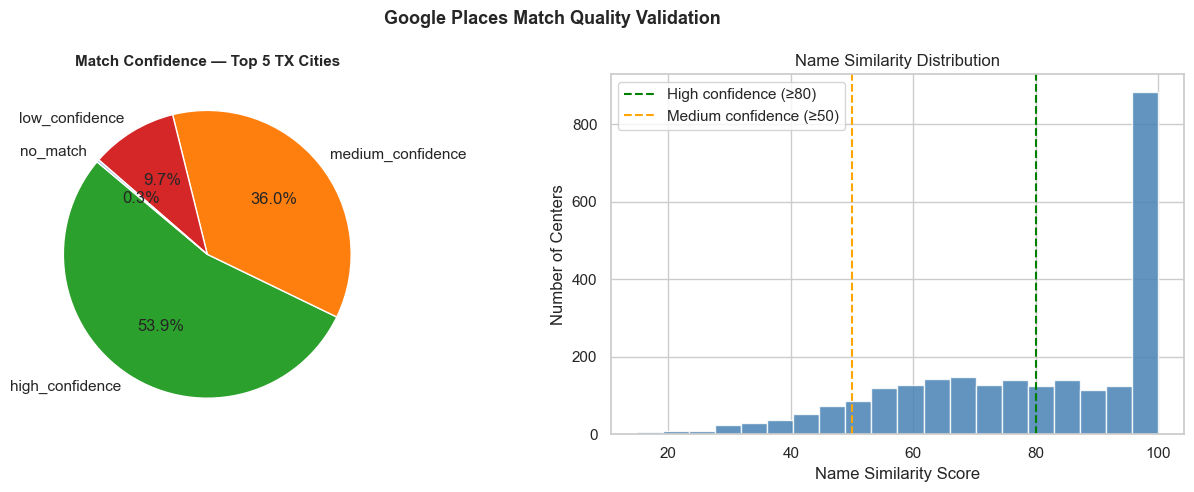

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conf_counts = df['match_confidence'].value_counts()
color_map   = {'high_confidence': '#2ca02c', 'medium_confidence': '#ff7f0e',
               'low_confidence': '#d62728',  'no_match': '#aec7e8'}
axes[0].pie(conf_counts.values, labels=conf_counts.index, autopct='%1.1f%%',
            colors=[color_map.get(k, 'grey') for k in conf_counts.index], startangle=140)
axes[0].set_title('Match Confidence — Top 5 TX Cities', fontsize=11, fontweight='bold')

matched_df = df[df['place_id'].notna()]
axes[1].hist(matched_df['name_similarity'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(80, color='green',  linestyle='--', linewidth=1.5, label='High confidence (≥80)')
axes[1].axvline(50, color='orange', linestyle='--', linewidth=1.5, label='Medium confidence (≥50)')
axes[1].set_xlabel('Name Similarity Score')
axes[1].set_ylabel('Number of Centers')
axes[1].set_title('Name Similarity Distribution')
axes[1].legend()

plt.suptitle('Google Places Match Quality Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'match_quality_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Fetch Google Ratings and Reviews

For each high- or medium-confidence match, the `place/details` API is called to retrieve:
- `rating` — the overall Google star rating (the **model target**)
- `user_ratings_total` — total review count on the platform
- `reviews` — up to 5 most-relevant review texts and individual ratings

Results are cached; re-running the cell skips already-fetched records.

In [9]:
def get_place_details(place_id, api_key=GOOGLE_API_KEY):
    url    = "https://maps.googleapis.com/maps/api/place/details/json"
    params = {'place_id': place_id,
               # Fetch only the fields we need — billing is per field; unused fields cost extra
               'fields':  'name,rating,user_ratings_total,reviews',
               'key':     api_key}
    try:
        resp    = requests.get(url, params=params, timeout=10)
        data    = resp.json().get('result', {})
        reviews = data.get('reviews', [])
        return {
            'google_rating':          data.get('rating'),
            'google_review_count':    data.get('user_ratings_total'),
            # Google Places returns at most 5 reviews per call (API limit)
            'review_texts':           [r.get('text', '') for r in reviews],
            'review_ratings':         [r.get('rating') for r in reviews],
            'review_count_returned':  len(reviews),
        }
    except Exception as e:
        return {'google_rating': None, 'google_review_count': None,
                'review_texts': [], 'review_ratings': [], 'review_count_returned': 0}


if os.path.exists(DETAILS_CACHE):
    with open(DETAILS_CACHE) as f:
        details_cache = json.load(f)
    print(f"Loaded details cache: {len(details_cache)} records")
else:
    details_cache = {}
    print("Starting fresh details cache")

# Only fetch high/medium confidence matches — low confidence matches are likely wrong places
df_fetch     = df[df['match_confidence'].isin(['high_confidence', 'medium_confidence'])].copy()
already_done = sum(1 for pid in df_fetch['place_id'] if pid in details_cache)
remaining    = len(df_fetch) - already_done
print(f"Centers to fetch: {len(df_fetch):,} | Cached: {already_done:,} | Remaining: {remaining:,}")
print(f"Estimated API cost: ~${remaining * 0.017:.2f}")

Loaded details cache: 2192 records
Centers to fetch: 2,264 | Cached: 2,264 | Remaining: 0
Estimated API cost: ~$0.00


In [10]:
detail_rows  = []
start_time   = time.time()
already_done = sum(1 for pid in df_fetch['place_id'] if pid in details_cache)

for i, (_, row) in enumerate(df_fetch.iterrows()):
    pid = row['place_id']
    if pid in details_cache:
        # Cache hit — no API call needed
        detail_rows.append({'place_id': pid, **details_cache[pid]})
    else:
        details = get_place_details(pid)
        details_cache[pid] = details
        detail_rows.append({'place_id': pid, **details})
        time.sleep(0.05)  # stay within Google's 50 QPS rate limit

    # Flush cache every 50 records so an interrupted run loses at most 50 API calls
    if (i + 1) % 50 == 0 or (i + 1) == len(df_fetch):
        elapsed       = time.time() - start_time
        api_calls     = i + 1 - already_done  # exclude cached records from rate calculation
        rate          = api_calls / elapsed if elapsed > 0 else 0
        remaining_now = len(df_fetch) - (i + 1)
        eta           = (remaining_now / rate) / 60 if rate > 0 else 0
        with_rating   = sum(1 for r in detail_rows if r.get('google_rating'))

        print(f"  [{i+1:>4}/{len(df_fetch)}] with ratings: {with_rating:,} | city: {row['CITY']:<12} | "
              f"elapsed: {elapsed/60:.1f}m | ETA: {eta:.1f}m")

        with open(DETAILS_CACHE, 'w') as f:
            json.dump(details_cache, f)

# Final flush ensures the last batch is written even if len(df_fetch) is not a multiple of 50
with open(DETAILS_CACHE, 'w') as f:
    json.dump(details_cache, f)

# Merge ratings back to the matched centers dataframe
df_details    = pd.DataFrame(detail_rows)
df_final      = df_fetch.merge(df_details, on='place_id', how='left')
total_elapsed = (time.time() - start_time) / 60

print(f"\nDetails complete in {total_elapsed:.1f} minutes:")
print(f"  Centers with ratings:    {df_final['google_rating'].notna().sum():,}")
print(f"  Centers with 3+ reviews: {(df_final['review_count_returned'] >= 3).sum():,}")
print(f"  Total reviews collected: {int(df_final['review_count_returned'].sum()):,}")

  [  50/2264] with ratings: 41 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 100/2264] with ratings: 82 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 150/2264] with ratings: 113 | city: SAN ANTONIO  | elapsed: 0.0m | ETA: 0.0m
  [ 200/2264] with ratings: 156 | city: HOUSTON      | elapsed: 0.0m | ETA: 0.0m
  [ 250/2264] with ratings: 194 | city: FORT WORTH   | elapsed: 0.0m | ETA: 0.0m
  [ 300/2264] with ratings: 230 | city: AUSTIN       | elapsed: 0.0m | ETA: 0.0m
  [ 350/2264] with ratings: 271 | city: FORT WORTH   | elapsed: 0.0m | ETA: 0.0m
  [ 400/2264] with ratings: 309 | city: DALLAS       | elapsed: 0.0m | ETA: 0.0m
  [ 450/2264] with ratings: 343 | city: AUSTIN       | elapsed: 0.0m | ETA: 0.0m
  [ 500/2264] with ratings: 383 | city: FORT WORTH   | elapsed: 0.0m | ETA: 0.0m
  [ 550/2264] with ratings: 424 | city: SAN ANTONIO  | elapsed: 0.0m | ETA: 0.0m
  [ 600/2264] with ratings: 465 | city: FORT WORTH   | elapsed: 0.0m | ETA: 0.0m
  [ 650/2264] with ratings: 51

## 5. Data Collection Coverage Assessment

       CITY  centers_total  with_rating  with_reviews  total_reviews  mean_rating  median_rating  match_rate
     AUSTIN            460          315           315           1434     4.611746            4.7        68.5
     DALLAS            318          245           245           1103     4.368163            4.6        77.0
 FORT WORTH            292          236           236           1147     4.513983            4.7        80.8
    HOUSTON            923          735           735           3432     4.479864            4.6        79.6
SAN ANTONIO            475          413           413           1958     4.358838            4.5        86.9


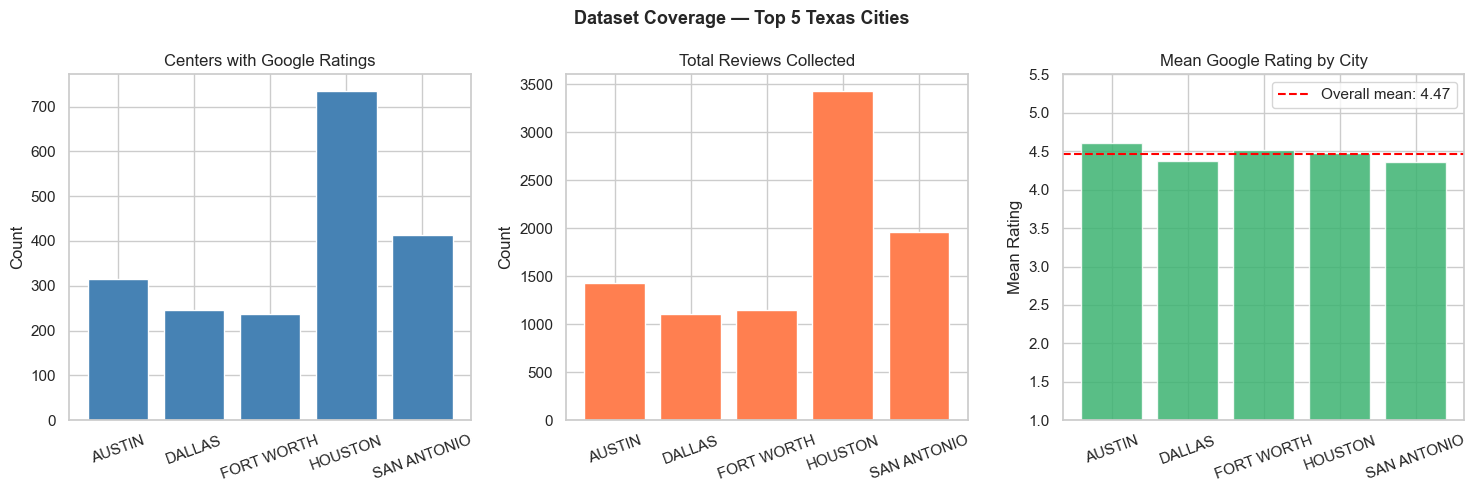

COVERAGE SUMMARY — TOP 5 TEXAS CITIES
HHSC Licensed Centers (5 cities):    2,516
Matched to Google Places:             2,509 (99.7%)
High/medium confidence matches:       2,264
Centers with star ratings:            1,944
Centers with reviews (any):           1,944
Total review texts collected:         9,074
Model 1 usable records:               1,944
Model 2 usable records:               1,944  (centers with >= 1 review)


In [11]:
city_summary = df_final.groupby('CITY').agg(
    centers_total      = ('OPERATION_ID', 'count'),
    with_rating        = ('google_rating', lambda x: x.notna().sum()),
    with_reviews = ('review_count_returned', lambda x: (x >= 1).sum()),
    total_reviews      = ('review_count_returned', 'sum'),
    mean_rating        = ('google_rating', 'mean'),
    median_rating      = ('google_rating', 'median'),
).reset_index()
city_summary['match_rate'] = (city_summary['with_rating'] /
                               city_summary['centers_total'] * 100).round(1)
print(city_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(city_summary['CITY'], city_summary['with_rating'], color='steelblue')
axes[0].set_title('Centers with Google Ratings')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(city_summary['CITY'], city_summary['total_reviews'], color='coral')
axes[1].set_title('Total Reviews Collected')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(city_summary['CITY'], city_summary['mean_rating'],
            color='mediumseagreen', alpha=0.85)
overall_mean = df_final['google_rating'].mean()
axes[2].axhline(overall_mean, color='red', linestyle='--',
                label=f'Overall mean: {overall_mean:.2f}')
axes[2].set_ylim(1, 5.5)
axes[2].set_title('Mean Google Rating by City')
axes[2].set_ylabel('Mean Rating')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend()

plt.suptitle('Dataset Coverage — Top 5 Texas Cities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'coverage_assessment.png'), dpi=150, bbox_inches='tight')
plt.show()

model1_n      = df_final['google_rating'].notna().sum()
model2_n      = (df_final['review_count_returned'] >= 1).sum()
total_reviews = int(df_final['review_count_returned'].sum())

print("=" * 55)
print("COVERAGE SUMMARY — TOP 5 TEXAS CITIES")
print("=" * 55)
print(f"HHSC Licensed Centers (5 cities):    {len(df):,}")
print(f"Matched to Google Places:             {df['place_id'].notna().sum():,} ({df['place_id'].notna().sum()/len(df)*100:.1f}%)")
print(f"High/medium confidence matches:       {len(df_fetch):,}")
print(f"Centers with star ratings:            {model1_n:,}")
print(f"Centers with reviews (any):           {model2_n:,}")
print(f"Total review texts collected:         {total_reviews:,}")
print(f"Model 1 usable records:               {model1_n:,}")
print(f"Model 2 usable records:               {model2_n:,}  (centers with >= 1 review)")
print("=" * 55)

## 6. Checkpoint — Save

Saves `df_final` to disk before feature engineering begins. This preserves the output of the two expensive API pipelines (Sections 2 and 4) so that Sections 7 onwards can be re-run without repeating the data collection.


In [12]:
# ── Checkpoint: save df_final before feature engineering modifies it ─────
# df_final at this point is the output of the two expensive API pipelines:
#   #2 Google Places matching  (~$42, ~13 min)
#   #4 Fetch ratings & reviews (~$35, ~13 min)
# Saving it here means #6 onwards can be re-run without repeating those calls.
#
# Pickle is used (not CSV) because review_texts and review_ratings are Python
# lists — CSV would silently convert them to strings, breaking Section 8.5 and Section 10.

CHECKPOINT_PATH = os.path.join(PROCESSED_DIR, 'df_matched_rated.pkl')
df_final.to_pickle(CHECKPOINT_PATH)

size_mb = os.path.getsize(CHECKPOINT_PATH) / 1024 / 1024
print(f"Checkpoint saved: {CHECKPOINT_PATH}")
print(f"  Shape:     {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"  File size: {size_mb:.1f} MB")
print()
print("To reload and skip Section 1–Section 5 on future runs:")
print("  df_final = pd.read_pickle(CHECKPOINT_PATH)")

Checkpoint saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_matched_rated.pkl
  Shape:     2,468 rows × 55 columns
  File size: 5.3 MB

To reload and skip Section 1–Section 5 on future runs:
  df_final = pd.read_pickle(CHECKPOINT_PATH)


## 7. Checkpoint — Reload

Loads `df_final` from the saved checkpoint. Run Sections 0, 6, and this cell to resume from the checkpoint — bypassing the HHSC download and both Google Places API calls.


In [3]:
# ── Reload checkpoint (skip Sections 1–5 on re-runs) ─────────────────────
# Run Section 0 first, then run this cell, then continue from Section 6.
# This loads df_final from the pickle saved at the end of Section 5,
# bypassing the HHSC download and both Google Places API calls.

CHECKPOINT_PATH = os.path.join(PROCESSED_DIR, 'df_matched_rated.pkl')

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}\n"
        "Run Sections 1–5 once to generate it."
    )

df_final = pd.read_pickle(CHECKPOINT_PATH)
print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
print(f"  Shape: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print(f"  Columns: {list(df_final.columns)}")

Loaded checkpoint: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_matched_rated.pkl
  Shape: 2,468 rows x 55 columns
  Columns: ['OPERATION_ID', 'OPERATION_TYPE', 'OPERATION_NUMBER', 'OPERATION_NAME', 'PROGRAMS_PROVIDED', 'LOCATION_ADDRESS', 'MAILING_ADDRESS', 'PHONE_NUMBER', 'COUNTY', 'WEBSITE_ADDRESS', 'ADMINISTRATOR_DIRECTOR_NAME', 'TYPE_OF_ISSUANCE', 'ISSUANCE_DATE', 'CONDITIONS_ON_PERMIT', 'ACCEPTS_CHILD_CARE_SUBSIDIES', 'HOURS_OF_OPERATION', 'DAYS_OF_OPERATION', 'OTHER_SCHEDULE_INFORMATION', 'TOTAL_CAPACITY', 'OPEN_FOSTER_HOMES', 'OPEN_BRANCH_OFFICES', 'LICENSED_TO_SERVE_AGES', 'CORRECTIVE_ACTION', 'ADVERSE_ACTION', 'TEMPORARILY_CLOSED', 'PROGRAMMATIC_SERVICES', 'TREATMENT_SERVICES', 'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM', 'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'TOTAL_REPORTS', 'TOTAL_SELF_REPORTS', 'Location_address_geo', 'email_address', 'CA

## 8. Data Preparation — Center-Level Consolidation

The raw  loaded from the checkpoint contains 2,468 rows — some HHSC-registered programs share the same physical location and Google Places listing. This section aggregates the compliance features across all programs at each unique location () to produce one center-level row per Google Places listing. This ensures the unit of analysis matches the Google rating, which reflects the physical location, not an individual HHSC program.

**Column reduction:** The checkpoint has 55 columns. The aggregation retains only the 26 model-relevant columns (plus ), dropping 28 administrative and metadata fields that are not used in modelling (contact info, operational schedules, redundant match fields, etc.). Section 9 then adds 9 derived features (binary flags, deficiency rates, years in operation), bringing the final working dataset to **36 columns**.


### 8.1 Aggregate by Place ID

In [4]:
# Aggregate compliance features by place_id — one row per unique physical location
# Multiple HHSC programs at the same location share one Google Places listing and one rating
# Aggregation rules reflect what each feature type represents:
#   Sum   — total counts across all programs (total inspections, deficiency counts)
#   Max   — capacity: preserve the largest program value
#   First — text/date source fields: use the first matched program
#           (87.4% of centres are single-program; for 276 multi-program centres,
#            binary flag source fields use the first program record)
# NOTE: Derived columns (IS_ACCREDITED, DEFICIENCY_RATE, YEARS_IN_OPERATION, etc.)
#       are computed in Section 9 AFTER this aggregation step.
#       Source columns needed for those derivations are retained here via "first".

# Convert count columns to numeric BEFORE aggregation.
# These are stored as strings in the checkpoint; pandas would concatenate
# strings instead of summing them, producing values like 3.33e+63.
_sum_cols = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'TOTAL_CAPACITY',
]
for _col in _sum_cols:
    if _col in df_final.columns:
        df_final[_col] = pd.to_numeric(df_final[_col], errors='coerce')

n_raw = len(df_final)

agg_rules = {
    # Sum — total counts across all programs at the location
    'DEFICIENCY_HIGH':              'sum',
    'DEFICIENCY_MEDIUM_HIGH':       'sum',
    'DEFICIENCY_MEDIUM':            'sum',
    'DEFICIENCY_MEDIUM_LOW':        'sum',
    'DEFICIENCY_LOW':               'sum',
    'TOTAL_INSPECTIONS':            'sum',
    'TOTAL_ASSESSMENTS':            'sum',
    # Max — preserve the largest capacity across programs
    'TOTAL_CAPACITY':               'max',
    # First — source fields for Section 9 feature engineering
    'ISSUANCE_DATE':                'first',  # -> YEARS_IN_OPERATION (Section 9.1)
    'PROGRAMS_PROVIDED':            'first',  # -> IS_ACCREDITED (Section 9.2)
    'ACCEPTS_CHILD_CARE_SUBSIDIES': 'first',  # -> ACCEPTS_SUBSIDIES (Section 9.2)
    'CORRECTIVE_ACTION':            'first',  # -> HAS_CORRECTIVE_ACTION (Section 9.2)
    'ADVERSE_ACTION':               'first',  # -> HAS_ADVERSE_ACTION (Section 9.2)
    'TEMPORARILY_CLOSED':           'first',  # -> WAS_TEMP_CLOSED (Section 9.2)
    # First — identity and Google Places data
    'OPERATION_ID':                 'first',
    'OPERATION_NAME':               'first',
    'CITY':                         'first',
    'ADDRESS_LINE':                 'first',
    'ZIPCODE':                      'first',
    'google_name':                  'first',
    'google_rating':                'first',
    'google_review_count':          'first',
    'review_texts':                 'first',
    'review_ratings':               'first',
    'review_count_returned':        'first',
    'match_confidence':             'first',
}

# Keep only columns that exist in df_final
agg_rules_filtered = {k: v for k, v in agg_rules.items() if k in df_final.columns}

dropped = [k for k in agg_rules if k not in agg_rules_filtered]
if dropped:
    print(f"WARNING: columns in agg_rules not found in df_final: {dropped}")
else:
    print("All agg_rules columns found in df_final.")

df_final = df_final.groupby('place_id', as_index=False).agg(agg_rules_filtered)
n_agg = len(df_final)

print(f'Aggregation complete:')
print(f'  Before: {n_raw:,} program-level rows')
print(f'  After : {n_agg:,} centre-level rows (unique place_ids)')
print(f'  Consolidated: {n_raw - n_agg:,} duplicate program rows merged')
print(f'  Columns retained: {df_final.shape[1]}')


All agg_rules columns found in df_final.
Aggregation complete:
  Before: 2,468 program-level rows
  After : 2,192 centre-level rows (unique place_ids)
  Consolidated: 276 duplicate program rows merged
  Columns retained: 27


### 8.2 Modelling Dataset Summary

In [5]:
# Modelling-ready coverage summary — describes the aggregated dataset, not the raw pipeline
multi_prog = n_raw - n_agg
single_prog = n_agg - multi_prog  # centres that needed no aggregation

print('=' * 55)
print('MODELLING DATASET — UNIQUE CENTRES')
print('=' * 55)
print(f'Unique centres (place_ids)      : {n_agg:,}')
print(f'  Single-program centres         : {n_agg - multi_prog:,}')
print(f'  Multi-program centres merged   : {multi_prog:,}')
print()
print(f'Centres with star ratings        : {df_final["google_rating"].notna().sum():,}  (Model 1 usable)')
print(f'Centres with reviews (any)       : {(df_final["review_count_returned"] >= 1).sum():,}  (Model 2 usable)')
print()
rated = df_final[df_final['google_rating'].notna()]['google_rating']
print(f'Rating distribution (n={len(rated):,}):')
print(f'  Mean   : {rated.mean():.3f}')
print(f'  Median : {rated.median():.3f}')
print(f'  Std    : {rated.std():.3f}')
print('=' * 55)


MODELLING DATASET — UNIQUE CENTRES
Unique centres (place_ids)      : 2,192
  Single-program centres         : 1,916
  Multi-program centres merged   : 276

Centres with star ratings        : 1,697  (Model 1 usable)
Centres with reviews (any)       : 1,697  (Model 2 usable)

Rating distribution (n=1,697):
  Mean   : 4.456
  Median : 4.600
  Std    : 0.584


### 8.3 Key Uniqueness Verification

In [6]:
# Verify key uniqueness after aggregation
n_rows      = len(df_final)
n_place_ids = df_final["place_id"].nunique()
n_op_ids    = df_final["OPERATION_ID"].nunique()
n_rated     = df_final["google_rating"].notna().sum()

print(f"Total rows            : {n_rows:,}")
print(f"Unique place_ids      : {n_place_ids:,}  (primary key)")
print(f"Unique OPERATION_IDs  : {n_op_ids:,}")
print()
if n_rows == n_place_ids:
    print("place_id is unique per row - confirmed primary key")
else:
    print(f"WARNING: {n_rows - n_place_ids} duplicate place_ids exist")

if n_rows == n_op_ids:
    print("OPERATION_ID is also unique per row")
else:
    print(f"NOTE: {n_rows - n_op_ids} OPERATION_IDs are shared (multi-program centres kept first only)")

print()
print(f"Rated centres (Model 1/2 usable): {n_rated:,}")


Total rows            : 2,192
Unique place_ids      : 2,192  (primary key)
Unique OPERATION_IDs  : 2,192

place_id is unique per row - confirmed primary key
OPERATION_ID is also unique per row

Rated centres (Model 1/2 usable): 1,697


### 8.4 Coverage Plot

       CITY  centers_total  with_rating  with_reviews  total_reviews  mean_rating  median_rating  match_rate
     AUSTIN            387          271           271           1244     4.605535            4.7        70.0
     DALLAS            303          230           230           1040     4.372609            4.6        75.9
 FORT WORTH            220          164           164            787     4.454268            4.5        74.5
    HOUSTON            842          654           654           3066     4.464832            4.6        77.7
SAN ANTONIO            440          378           378           1798     4.384392            4.5        85.9


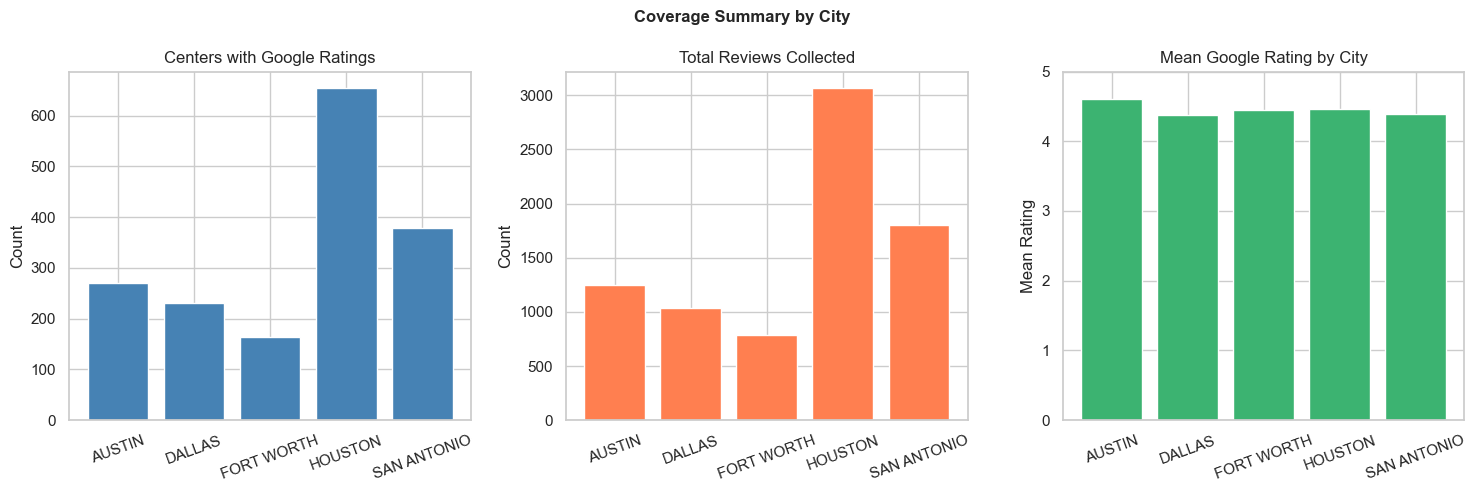


COVERAGE SUMMARY — TOP 5 TEXAS CITIES
High/medium confidence matches:       2,192
Centers with star ratings:            1,697
Centers with reviews (any):           1,697
Total review texts collected:         7,935
Model 1 usable records:               1,697
Model 2 usable records:               1,697  (centers with >= 1 review)


In [8]:
# Coverage summary — checkpoint path (mirrors Cell 19 using df_final only).
# df, df_fetch not available when using checkpoint; all stats derived from df_final.

city_summary = df_final.groupby('CITY').agg(
    centers_total      = ('OPERATION_ID', 'count'),
    with_rating        = ('google_rating', lambda x: x.notna().sum()),
    with_reviews       = ('review_count_returned', lambda x: (x >= 1).sum()),
    total_reviews      = ('review_count_returned', 'sum'),
    mean_rating        = ('google_rating', 'mean'),
    median_rating      = ('google_rating', 'median'),
).reset_index()
city_summary['match_rate'] = (city_summary['with_rating'] /
                               city_summary['centers_total'] * 100).round(1)
print(city_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(city_summary['CITY'], city_summary['with_rating'], color='steelblue')
axes[0].set_title('Centers with Google Ratings')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(city_summary['CITY'], city_summary['total_reviews'], color='coral')
axes[1].set_title('Total Reviews Collected')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(city_summary['CITY'], city_summary['mean_rating'], color='mediumseagreen')
axes[2].set_title('Mean Google Rating by City')
axes[2].set_ylabel('Mean Rating')
axes[2].set_ylim(0, 5)
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Coverage Summary by City', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', '8_4_consolidated_coverage_assessment.png'), dpi=150, bbox_inches='tight')
plt.show()

model1_n  = df_final['google_rating'].notna().sum()
model2_n  = (df_final['review_count_returned'] >= 1).sum()
hm_conf   = df_final['match_confidence'].isin(['high_confidence','medium_confidence']).sum()
total_rev = int(df_final['review_count_returned'].sum())

print()
print('=' * 55)
print('COVERAGE SUMMARY — TOP 5 TEXAS CITIES')
print('=' * 55)
print(f'High/medium confidence matches:       {hm_conf:,}')
print(f'Centers with star ratings:            {model1_n:,}')
print(f'Centers with reviews (any):           {model2_n:,}')
print(f'Total review texts collected:         {total_rev:,}')
print(f'Model 1 usable records:               {model1_n:,}')
print(f'Model 2 usable records:               {model2_n:,}  (centers with >= 1 review)')
print('=' * 55)


## 9. Feature Engineering

15 regulatory features are engineered from raw HHSC fields for Model 1. Feature engineering is applied after Google Places matching and center-level aggregation (Section 8), so all transformations operate on unique center records rather than individual HHSC program rows.

| Category | Features |
|---|---|
| Violation severity | DEFICIENCY_HIGH / MEDIUM_HIGH / MEDIUM / MEDIUM_LOW / LOW |
| Derived rates | TOTAL_DEFICIENCIES, DEFICIENCY_RATE, HIGH_DEFICIENCY_RATE |
| Scale & history | TOTAL_CAPACITY, TOTAL_INSPECTIONS, TOTAL_ASSESSMENTS, YEARS_IN_OPERATION |
| Binary flags | IS_ACCREDITED, ACCEPTS_SUBSIDIES, HAS_CORRECTIVE_ACTION, HAS_ADVERSE_ACTION, WAS_TEMP_CLOSED |


### 9.1 Type Casting & Date Parsing

In [9]:
# ── Type casting ────────────────────────────────────────────────────────
# All columns were loaded as strings (dtype=str). Convert count/capacity
# columns to numeric; errors='coerce' turns unparseable values into NaN
# rather than raising an exception.
# TOTAL_REPORTS and TOTAL_SELF_REPORTS were excluded from the Section 8
# aggregation rules and are no longer present in df_final.
numeric_cols = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW',
    'TOTAL_CAPACITY', 'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS',
]
for col in numeric_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_final['ISSUANCE_DATE'] = pd.to_datetime(df_final['ISSUANCE_DATE'], errors='coerce')
# Divide by 365.25 (not 365) to correctly account for leap years
df_final['YEARS_IN_OPERATION'] = ((REFERENCE_DATE - df_final['ISSUANCE_DATE']).dt.days / 365.25).round(1)

print(f"Numeric columns cast: {len(numeric_cols)}")
print(f"YEARS_IN_OPERATION range: {df_final['YEARS_IN_OPERATION'].min():.1f} - {df_final['YEARS_IN_OPERATION'].max():.1f} years")


Numeric columns cast: 8
YEARS_IN_OPERATION range: -0.3 - 40.4 years


### 9.2 Binary Flag Encoding

In [10]:
# ── Binary flags ────────────────────────────────────────────────────────
# PROGRAMS_PROVIDED is a free-text field; substring search extracts accreditation status
df_final['IS_ACCREDITED']     = df_final['PROGRAMS_PROVIDED'].str.contains('Accredited', case=False, na=False).astype(int)
# ACCEPTS_CHILD_CARE_SUBSIDIES stores 'Y'/'N'; anything else (blank, unknown) becomes NaN
df_final['ACCEPTS_SUBSIDIES'] = df_final['ACCEPTS_CHILD_CARE_SUBSIDIES'].str.strip().str.upper().map({'Y': 1, 'N': 0})

# HHSC stores 'YES'/'NO' for all centers (never null) — check for 'YES' explicitly.
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED are all 'NO' in this dataset (zero variance)
# and are excluded from FEATURE_COLS; computed here for completeness only.
df_final['HAS_CORRECTIVE_ACTION'] = (df_final['CORRECTIVE_ACTION'].str.strip().str.upper() == 'YES').astype(int)
df_final['HAS_ADVERSE_ACTION']    = (df_final['ADVERSE_ACTION'].str.strip().str.upper() == 'YES').astype(int)
df_final['WAS_TEMP_CLOSED']       = (df_final['TEMPORARILY_CLOSED'].str.strip().str.upper() == 'YES').astype(int)

for col in ['IS_ACCREDITED','ACCEPTS_SUBSIDIES','HAS_CORRECTIVE_ACTION','HAS_ADVERSE_ACTION','WAS_TEMP_CLOSED']:
    n = df_final[col].sum()
    print(f"  {col:<25} {n:>4} / {len(df_final):,}  ({n/len(df_final)*100:.1f}%)")


  IS_ACCREDITED              324 / 2,192  (14.8%)
  ACCEPTS_SUBSIDIES         1205 / 2,192  (55.0%)
  HAS_CORRECTIVE_ACTION       12 / 2,192  (0.5%)
  HAS_ADVERSE_ACTION           0 / 2,192  (0.0%)
  WAS_TEMP_CLOSED              0 / 2,192  (0.0%)


### 9.3 Derived Rate Features

In [11]:
# ── Derived rate features ────────────────────────────────────────────────
# fillna(0) treats missing severity tiers as zero violations
df_final['TOTAL_DEFICIENCIES'] = (
    df_final['DEFICIENCY_HIGH'].fillna(0) + df_final['DEFICIENCY_MEDIUM_HIGH'].fillna(0) +
    df_final['DEFICIENCY_MEDIUM'].fillna(0) + df_final['DEFICIENCY_MEDIUM_LOW'].fillna(0) +
    df_final['DEFICIENCY_LOW'].fillna(0)
)
# replace(0, np.nan) on the denominator prevents division-by-zero producing inf
df_final['DEFICIENCY_RATE']      = (df_final['TOTAL_DEFICIENCIES'] /
                                     df_final['TOTAL_INSPECTIONS'].replace(0, np.nan)).round(3)
df_final['HIGH_DEFICIENCY_RATE'] = (df_final['DEFICIENCY_HIGH'].fillna(0) /
                                     df_final['TOTAL_INSPECTIONS'].replace(0, np.nan)).round(3)

print(f"DEFICIENCY_RATE      — mean: {df_final['DEFICIENCY_RATE'].mean():.3f}, max: {df_final['DEFICIENCY_RATE'].max():.3f}")
print(f"HIGH_DEFICIENCY_RATE — mean: {df_final['HIGH_DEFICIENCY_RATE'].mean():.3f}, max: {df_final['HIGH_DEFICIENCY_RATE'].max():.3f}")


DEFICIENCY_RATE      — mean: 1.074, max: 9.000
HIGH_DEFICIENCY_RATE — mean: 0.234, max: 1.474


### 9.4 Post-Engineering Summary

In [12]:
# Post-engineering validation — confirm all transforms ran correctly
print("=" * 55)
print("df_final — POST FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"Shape: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print()
print("── Columns & dtypes ─────────────────────────────────")
print(df_final.dtypes.to_string())
print()
print("── Records by city ──────────────────────────────────")
print(df_final['CITY'].value_counts().to_string())
print()
print("── Model eligibility ────────────────────────────────")
print(f"  With google_rating (Model 1 candidates): {df_final['google_rating'].notna().sum():,}")
print(f"  With 1+ reviews   (Model 2 candidates): {(df_final['review_count_returned'] >= 1).sum():,}")
print(f"  With 3+ reviews   (Model 2 preferred):  {(df_final['review_count_returned'] >= 3).sum():,}")
print()
print("── Missing values (all columns) ─────────────────────")
missing_all = df_final.isnull().sum()
missing_all = missing_all[missing_all > 0].sort_values(ascending=False)
print(missing_all.to_string() if len(missing_all) else "  None")
print()
print("── Engineered feature stats ─────────────────────────")
print(df_final[FEATURE_COLS].describe().round(2).to_string())
print("=" * 55)


df_final — POST FEATURE ENGINEERING SUMMARY
Shape: 2,192 rows x 36 columns

── Columns & dtypes ─────────────────────────────────
place_id                                object
DEFICIENCY_HIGH                          int64
DEFICIENCY_MEDIUM_HIGH                   int64
DEFICIENCY_MEDIUM                        int64
DEFICIENCY_MEDIUM_LOW                    int64
DEFICIENCY_LOW                           int64
TOTAL_INSPECTIONS                        int64
TOTAL_ASSESSMENTS                        int64
TOTAL_CAPACITY                           int64
ISSUANCE_DATE                   datetime64[ns]
PROGRAMS_PROVIDED                       object
ACCEPTS_CHILD_CARE_SUBSIDIES            object
CORRECTIVE_ACTION                       object
ADVERSE_ACTION                          object
TEMPORARILY_CLOSED                      object
OPERATION_ID                            object
OPERATION_NAME                          object
CITY                                    object
ADDRESS_LINE            

## 10. Data Overview & Cleaning

The engineered feature set is inspected for missing values and imputation is applied before EDA and modelling.

### 10.1 Missing Value Check

In [13]:
print(f"Dataset shape: {df_final.shape}")
print()
print("Missing values in regulatory features:")
missing = df_final[FEATURE_COLS].isnull().sum()
missing_nonzero = missing[missing > 0]
if len(missing_nonzero):
    print(missing_nonzero.to_string())
else:
    print("  None")
print()
df_final[FEATURE_COLS].describe().round(2)

Dataset shape: (2192, 36)

Missing values in regulatory features:
  None



,DEFICIENCY_HIGH,DEFICIENCY_MEDIUM_HIGH,DEFICIENCY_MEDIUM,DEFICIENCY_MEDIUM_LOW,DEFICIENCY_LOW,TOTAL_DEFICIENCIES,DEFICIENCY_RATE,HIGH_DEFICIENCY_RATE,TOTAL_CAPACITY,TOTAL_INSPECTIONS,TOTAL_ASSESSMENTS,YEARS_IN_OPERATION,IS_ACCREDITED,ACCEPTS_SUBSIDIES,HAS_CORRECTIVE_ACTION
count,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00
mean,3.48,6.11,3.78,0.54,0.19,14.11,1.07,0.23,122.01,12.91,0.44,13.30,0.15,0.55,0.01
std,4.81,8.03,5.09,1.05,0.55,17.09,0.89,0.22,82.66,16.96,0.98,12.22,0.35,0.50,0.07
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00,1.00,0.00,-0.30,0.00,0.00,0.00
25%,1.00,1.00,1.00,0.00,0.00,4.00,0.44,0.04,66.00,7.00,0.00,3.60,0.00,0.00,0.00
50%,2.00,4.00,2.00,0.00,0.00,9.00,0.88,0.20,100.00,10.00,0.00,9.20,0.00,1.00,0.00
75%,5.00,8.00,5.00,1.00,0.00,19.00,1.50,0.35,153.00,15.00,1.00,20.72,0.00,1.00,0.00
max,45.00,136.00,96.00,12.00,8.00,280.00,9.00,1.47,999.00,648.00,14.00,40.40,1.00,1.00,1.00


### 10.2 Imputation

In [14]:
# ── Imputation ────────────────────────────────────────────────────────────
# ACCEPTS_SUBSIDIES: map failures → 0 (conservative: assume no subsidy acceptance)
df_final['ACCEPTS_SUBSIDIES'] = df_final['ACCEPTS_SUBSIDIES'].fillna(0).astype(int)

# Rates: NaN arises when TOTAL_INSPECTIONS == 0 after filter; safe to fill with 0
df_final['DEFICIENCY_RATE']      = df_final['DEFICIENCY_RATE'].fillna(0)
df_final['HIGH_DEFICIENCY_RATE'] = df_final['HIGH_DEFICIENCY_RATE'].fillna(0)

# TOTAL_ASSESSMENTS: not all centers have formal assessments; NaN → 0
df_final['TOTAL_ASSESSMENTS'] = df_final['TOTAL_ASSESSMENTS'].fillna(0)

# YEARS_IN_OPERATION: clip negatives (data entry errors in ISSUANCE_DATE)
df_final['YEARS_IN_OPERATION'] = df_final['YEARS_IN_OPERATION'].clip(lower=0)

# Duplicate check
dupes = df_final['OPERATION_ID'].duplicated().sum()
print(f"Duplicate OPERATION_IDs: {dupes}")

print()
print("Missing values after imputation:")
missing_after = df_final[FEATURE_COLS].isnull().sum()
missing_after_nz = missing_after[missing_after > 0]
if len(missing_after_nz):
    print(missing_after_nz.to_string())
else:
    print("  None — all features complete")
print()
print("Data cleaning complete.")

Duplicate OPERATION_IDs: 0

Missing values after imputation:
  None — all features complete

Data cleaning complete.


### 10.3 Column Datatypes

In [15]:
# ── Column datatypes before export ───────────────────────────────────────
print(f"df_final: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print()
print(f"{'Column':<40} {'Dtype':<15} {'Non-Null':>10} {'Null':>8}")
print("-" * 78)
for col in df_final.columns:
    dtype   = str(df_final[col].dtype)
    non_null = df_final[col].notna().sum()
    null    = df_final[col].isna().sum()
    print(f"{col:<40} {dtype:<15} {non_null:>10,} {null:>8,}")


df_final: 2,192 rows x 36 columns

Column                                   Dtype             Non-Null     Null
------------------------------------------------------------------------------
place_id                                 object               2,192        0
DEFICIENCY_HIGH                          int64                2,192        0
DEFICIENCY_MEDIUM_HIGH                   int64                2,192        0
DEFICIENCY_MEDIUM                        int64                2,192        0
DEFICIENCY_MEDIUM_LOW                    int64                2,192        0
DEFICIENCY_LOW                           int64                2,192        0
TOTAL_INSPECTIONS                        int64                2,192        0
TOTAL_ASSESSMENTS                        int64                2,192        0
TOTAL_CAPACITY                           int64                2,192        0
ISSUANCE_DATE                            datetime64[ns]       2,192        0
PROGRAMS_PROVIDED                      

### 10.4 Export Cleaned Dataset

In [16]:
# ── Export cleaned dataset ────────────────────────────────────────────────
# Saved as pickle to preserve all dtypes — list columns (review_texts,
# review_ratings) are not representable in CSV and would silently corrupt.
# A CSV copy is also saved with list columns dropped for easy inspection.

CLEANED_PKL = os.path.join(PROCESSED_DIR, 'df_cleaned.pkl')
CLEANED_CSV = os.path.join(PROCESSED_DIR, 'df_cleaned.csv')

df_final.to_pickle(CLEANED_PKL)

# Drop list columns before writing CSV — they contain Python lists
list_cols   = [c for c in df_final.columns if df_final[c].apply(type).eq(list).any()]
df_final.drop(columns=list_cols).to_csv(CLEANED_CSV, index=False)

pkl_mb = os.path.getsize(CLEANED_PKL) / 1024 / 1024
csv_mb = os.path.getsize(CLEANED_CSV) / 1024 / 1024

print(f"Cleaned dataset exported:")
print(f"  {CLEANED_PKL}  ({pkl_mb:.1f} MB)  ← full dataset including review lists")
print(f"  {CLEANED_CSV}  ({csv_mb:.1f} MB)  ← flat CSV, list columns excluded: {list_cols}")
print()
print(f"Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")

Cleaned dataset exported:
  /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_cleaned.pkl  (4.7 MB)  ← full dataset including review lists
  /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_cleaned.csv  (0.7 MB)  ← flat CSV, list columns excluded: ['review_texts', 'review_ratings']

Shape: 2,192 rows × 36 columns


## 11. Exploratory Data Analysis

Before building any model, the data is explored to understand its structure, spot potential problems, and make informed decisions about how to prepare it for machine learning. The EDA is organised into seven subsections, each with a specific purpose.

| Subsection | What is Examined | Purpose |
|---|---|---|
| 11.1 Target Variable | Distribution of Google star ratings across all centers and cities | To understand what the model is predicting before choosing a metric or interpreting results |
| 11.2 Regulatory Feature Distributions | Distribution of each of the 15 engineered features | To identify features that are heavily skewed, dominated by zeros, or have very different scales |
| 11.3 Feature Correlations | Linear relationship between each regulatory feature and the Google rating, and between features themselves | To find which features are most likely to be useful predictors and whether any features are so similar that they may cause issues during modelling |
| 11.4 Scatter Plots | Relationship between four key regulatory features and Google rating, broken down by city | To visualise whether any single feature separates high-rated centers from low-rated ones and whether the pattern holds across cities |
| 11.5 Outlier Analysis | Extreme values in each continuous feature using the IQR method | To determine whether extreme values are data errors that should be removed or legitimate observations that should be kept |
| 11.6 Review Text Overview | Volume, length, and rating distribution of the review text corpus | To confirm the coverage and quality of the text data that will be used for Model 2 in the analysis notebook |
| 11.7 EDA Summary | Findings from all subsections combined | To draw conclusions that directly inform the modelling decisions in the analysis notebook |


### 11.1 Target Variable — Google Star Rating

The distribution of Google star ratings is examined across all centers and broken down by city.

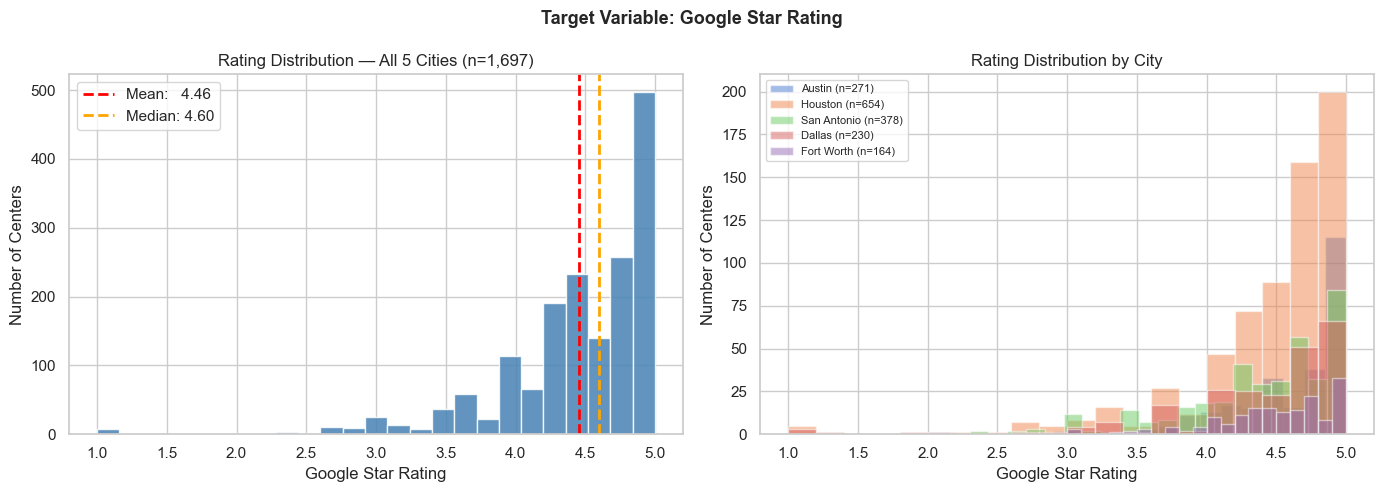

Count:  1,697
Mean:   4.456
Median: 4.60
Std:    0.584
Min / Max: 1.0 / 5.0

Rating Band   Centers       %
------------------------------
1.0 – 2.0          10    0.6%
2.0 – 3.0          25    1.5%
3.0 – 3.5          67    3.9%
3.5 – 4.0         132    7.8%
4.0 – 4.5         447   26.3%
4.5 – 5.0       1,016   59.9%


In [35]:
ratings = df_final['google_rating'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(ratings.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Mean:   {ratings.mean():.2f}')
axes[0].axvline(ratings.median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {ratings.median():.2f}')
axes[0].set_xlabel('Google Star Rating')
axes[0].set_ylabel('Number of Centers')
axes[0].set_title(f'Rating Distribution — All 5 Cities (n={len(ratings):,})')
axes[0].legend()

for city in TARGET_CITIES:
    subset = df_final[df_final['CITY'] == city]['google_rating'].dropna()
    if len(subset):
        axes[1].hist(subset, bins=20, alpha=0.5, label=f'{city.title()} (n={len(subset)})')
axes[1].set_xlabel('Google Star Rating')
axes[1].set_ylabel('Number of Centers')
axes[1].set_title('Rating Distribution by City')
axes[1].legend(fontsize=8)

plt.suptitle('Target Variable: Google Star Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_1_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Count:  {len(ratings):,}")
print(f"Mean:   {ratings.mean():.3f}")
print(f"Median: {ratings.median():.2f}")
print(f"Std:    {ratings.std():.3f}")
print(f"Min / Max: {ratings.min():.1f} / {ratings.max():.1f}")
bands = [
    ("1.0 – 2.0", (ratings >= 1.0) & (ratings <  2.0)),
    ("2.0 – 3.0", (ratings >= 2.0) & (ratings <  3.0)),
    ("3.0 – 3.5", (ratings >= 3.0) & (ratings <  3.5)),
    ("3.5 – 4.0", (ratings >= 3.5) & (ratings <  4.0)),
    ("4.0 – 4.5", (ratings >= 4.0) & (ratings <  4.5)),
    ("4.5 – 5.0", (ratings >= 4.5) & (ratings <= 5.0)),
]
print(f"\n{'Rating Band':<12} {'Centers':>8} {'%':>7}")
print("-" * 30)
for label, mask in bands:
    n = mask.sum()
    print(f"{label:<12} {n:>8,} {n/len(ratings)*100:>6.1f}%")

### 11.2 Regulatory Feature Distributions

The distribution of all 15 regulatory features is examined to understand scale, skew, and zero-inflation before modelling.

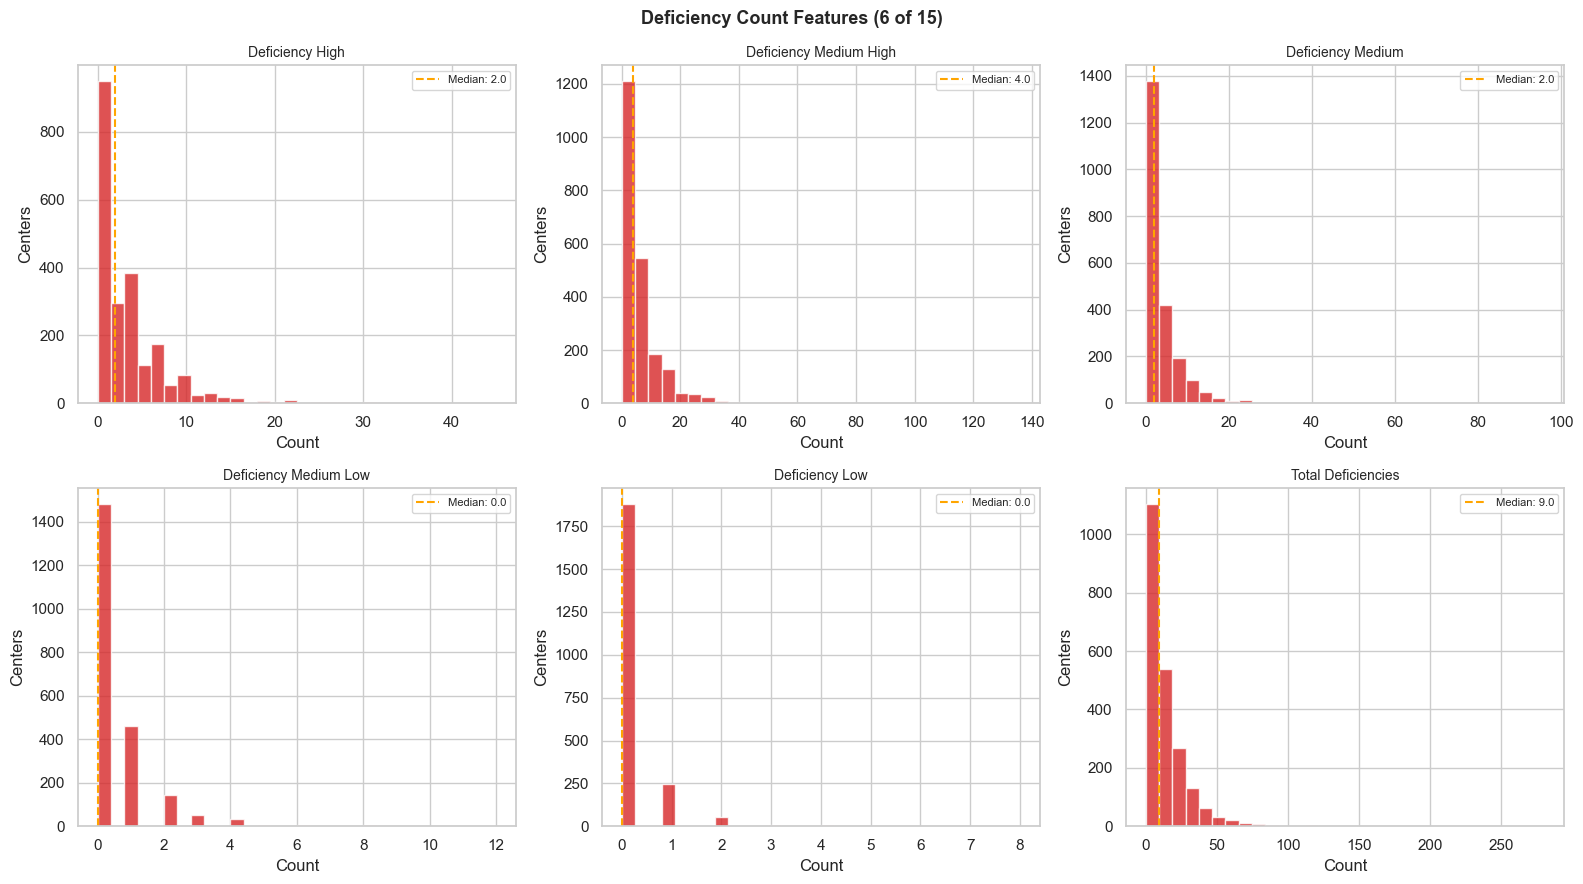

In [36]:
# Raw deficiency count features — how many violations of each severity tier
deficiency_counts = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, deficiency_counts):
    data = df_final[col].dropna()
    ax.hist(data, bins=30, color='#d62728', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Count')
    ax.set_ylabel('Centers')
    ax.legend(fontsize=8)

plt.suptitle('Deficiency Count Features (6 of 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_2_deficiency_counts.png'), dpi=150, bbox_inches='tight')
plt.show()


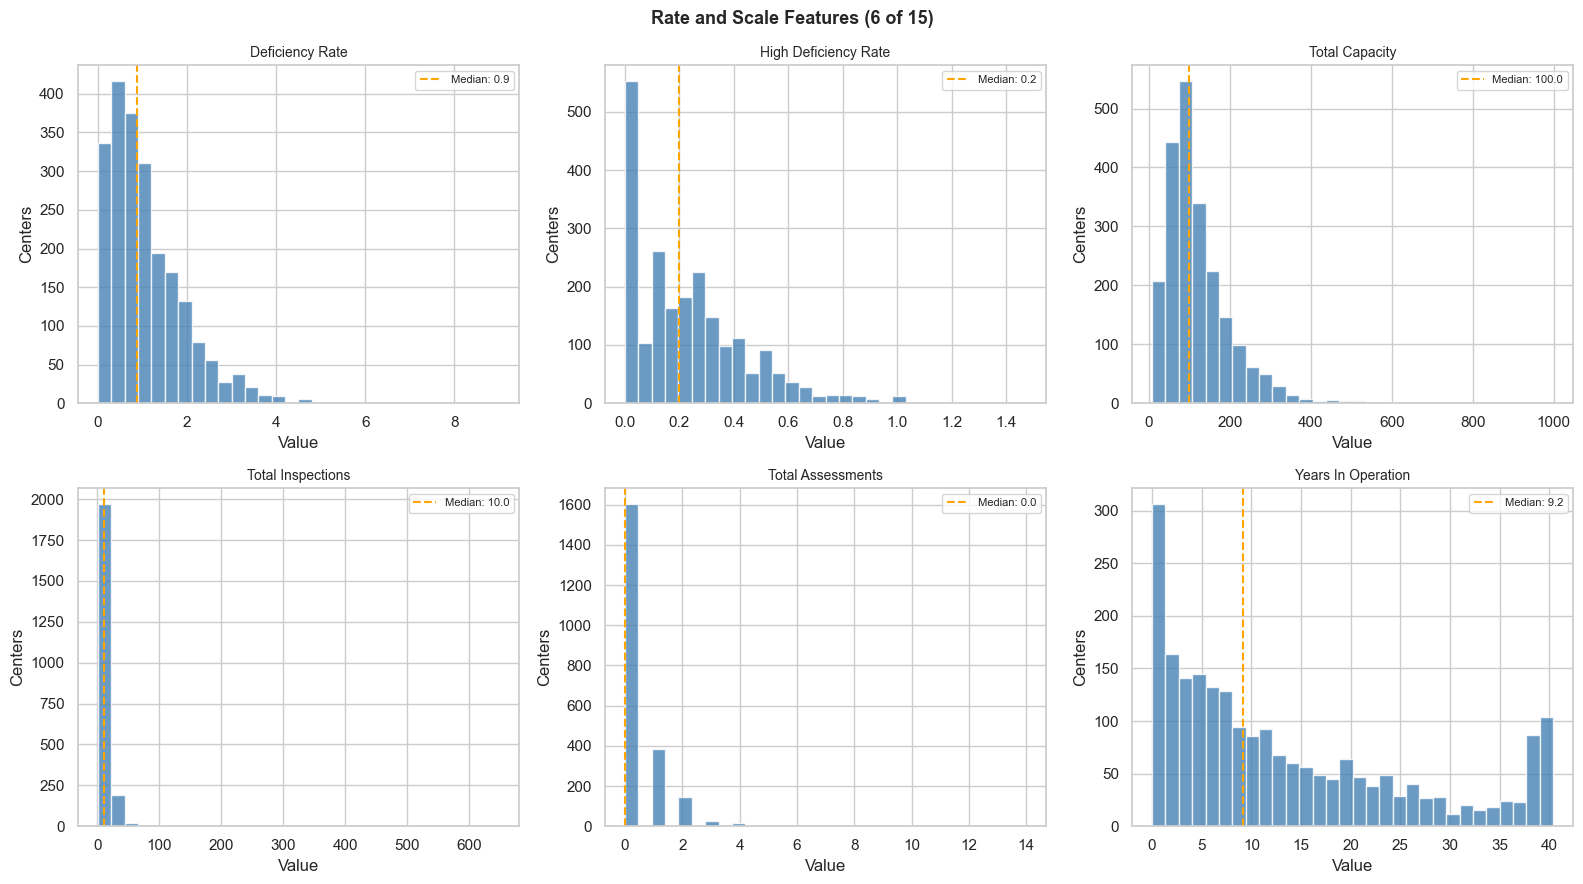

In [37]:
# Rate and scale features — normalised rates, size, and operational history
rate_scale = [
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, rate_scale):
    data = df_final[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Centers')
    ax.legend(fontsize=8)

plt.suptitle('Rate and Scale Features (6 of 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_2_rate_scale_features.png'), dpi=150, bbox_inches='tight')
plt.show()


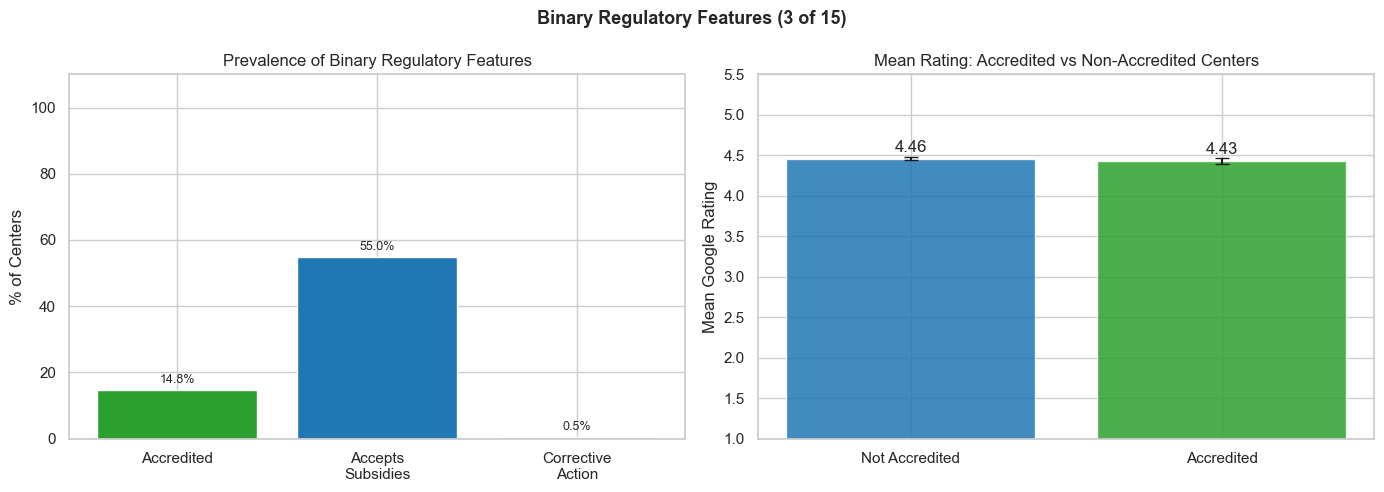

In [38]:
# Binary features — three flags used in modelling
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED excluded: zero variance in the 5-city active dataset
binary_features = ['IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION']
labels = ['Accredited', 'Accepts\nSubsidies', 'Corrective\nAction']
colors_bin = ['#2ca02c', '#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pcts = [df_final[f].sum() / len(df_final) * 100 for f in binary_features]
bars = axes[0].bar(labels, pcts, color=colors_bin)
axes[0].set_ylabel('% of Centers')
axes[0].set_title('Prevalence of Binary Regulatory Features')
axes[0].set_ylim(0, 110)
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

acc = df_final.groupby('IS_ACCREDITED')['google_rating'].agg(['mean', 'sem']).reset_index()
acc['label'] = acc['IS_ACCREDITED'].map({0: 'Not Accredited', 1: 'Accredited'})
axes[1].bar(acc['label'], acc['mean'], yerr=acc['sem'], capsize=5,
            color=['#1f77b4', '#2ca02c'], alpha=0.85)
axes[1].set_ylim(1, 5.5)
axes[1].set_ylabel('Mean Google Rating')
axes[1].set_title('Mean Rating: Accredited vs Non-Accredited Centers')
for i, row in acc.iterrows():
    axes[1].text(i, row['mean'] + 0.05, f"{row['mean']:.2f}", ha='center', va='bottom')

plt.suptitle('Binary Regulatory Features (3 of 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_2_binary_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### 11.3 Feature Correlations with Google Rating

The correlation between each of the 15 regulatory features and Google star rating is examined, along with pairwise correlations between features, to identify potential predictors and multicollinearity.

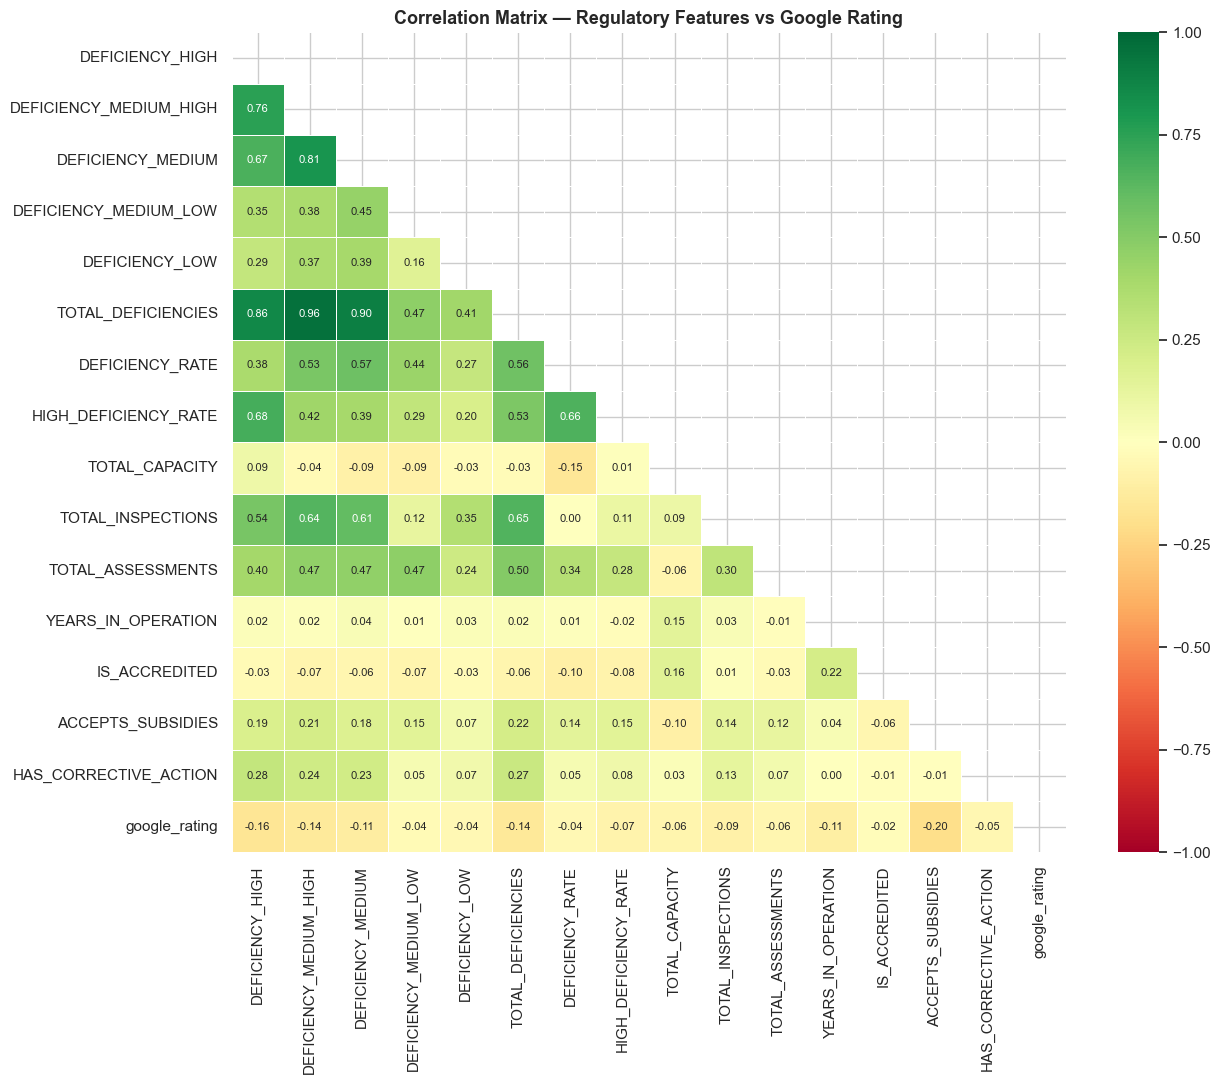

Feature correlations with Google Rating (sorted):
ACCEPTS_SUBSIDIES        -0.198
DEFICIENCY_HIGH          -0.160
TOTAL_DEFICIENCIES       -0.145
DEFICIENCY_MEDIUM_HIGH   -0.136
DEFICIENCY_MEDIUM        -0.111
YEARS_IN_OPERATION       -0.108
TOTAL_INSPECTIONS        -0.090
HIGH_DEFICIENCY_RATE     -0.072
TOTAL_CAPACITY           -0.063
TOTAL_ASSESSMENTS        -0.057
HAS_CORRECTIVE_ACTION    -0.049
DEFICIENCY_LOW           -0.043
DEFICIENCY_RATE          -0.039
DEFICIENCY_MEDIUM_LOW    -0.035
IS_ACCREDITED            -0.017


In [39]:
corr_cols   = FEATURE_COLS + ['google_rating']
corr_df     = df_final[corr_cols].dropna(subset=['google_rating'])
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title('Correlation Matrix — Regulatory Features vs Google Rating',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_3_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Feature correlations with Google Rating (sorted):")
print(corr_matrix['google_rating'].drop('google_rating').sort_values().round(3).to_string())

### 11.4 Scatter Plots: Regulatory Features vs Google Rating

All 12 continuous regulatory features are plotted against Google star rating, coloured by city, to show whether any feature separates high-rated centers from low-rated ones and whether any pattern holds consistently across geographies. Binary features are excluded as 0/1 values do not produce meaningful scatter plots.

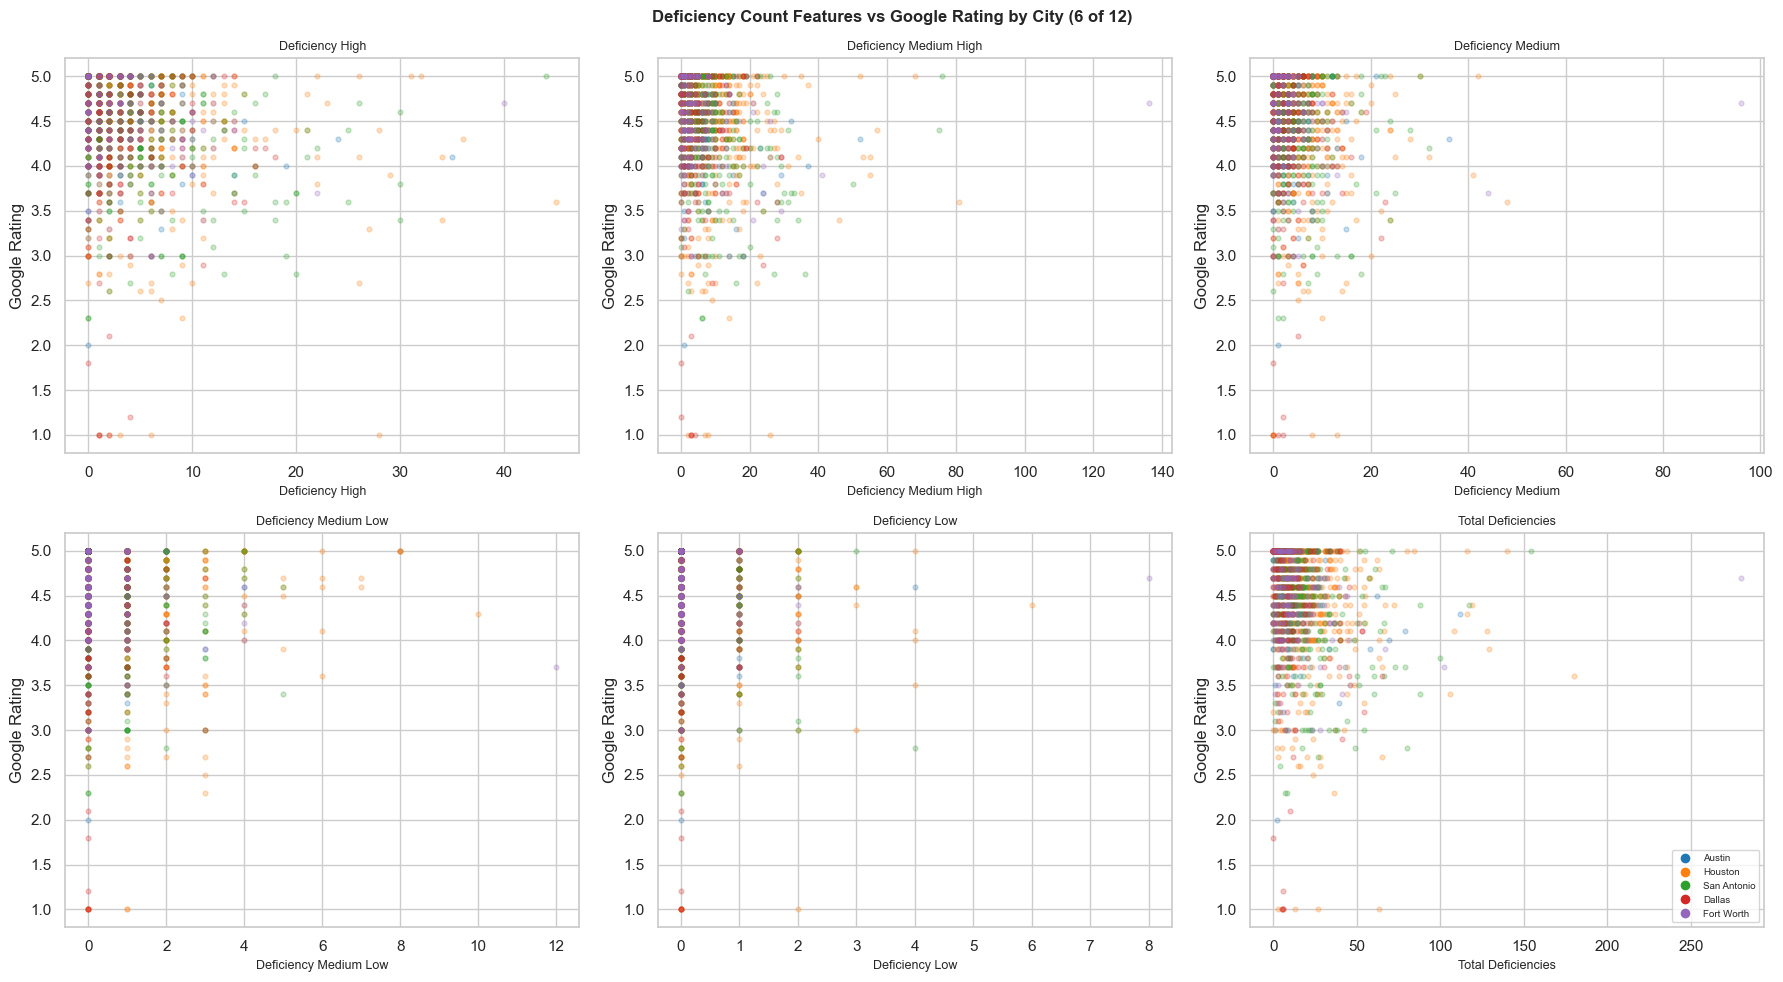

In [40]:
scatter_group = ['DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM', 'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES']
plot_df = df_final[scatter_group + ['google_rating', 'CITY']].dropna(subset=['google_rating'])

city_colors = dict(zip(TARGET_CITIES,
                       ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, scatter_group):
    for city in TARGET_CITIES:
        sub = plot_df[plot_df['CITY'] == city]
        ax.scatter(sub[col], sub['google_rating'],
                   alpha=0.25, s=12, color=city_colors[city], label=city.title())
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Google Rating')
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=city_colors[c], markersize=8, label=c.title())
           for c in TARGET_CITIES]
axes[-1].legend(handles=handles, fontsize=7, loc='lower right')

plt.suptitle('Deficiency Count Features vs Google Rating by City (6 of 12)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_4_scatter_deficiency_counts.png'), dpi=150, bbox_inches='tight')
plt.show()


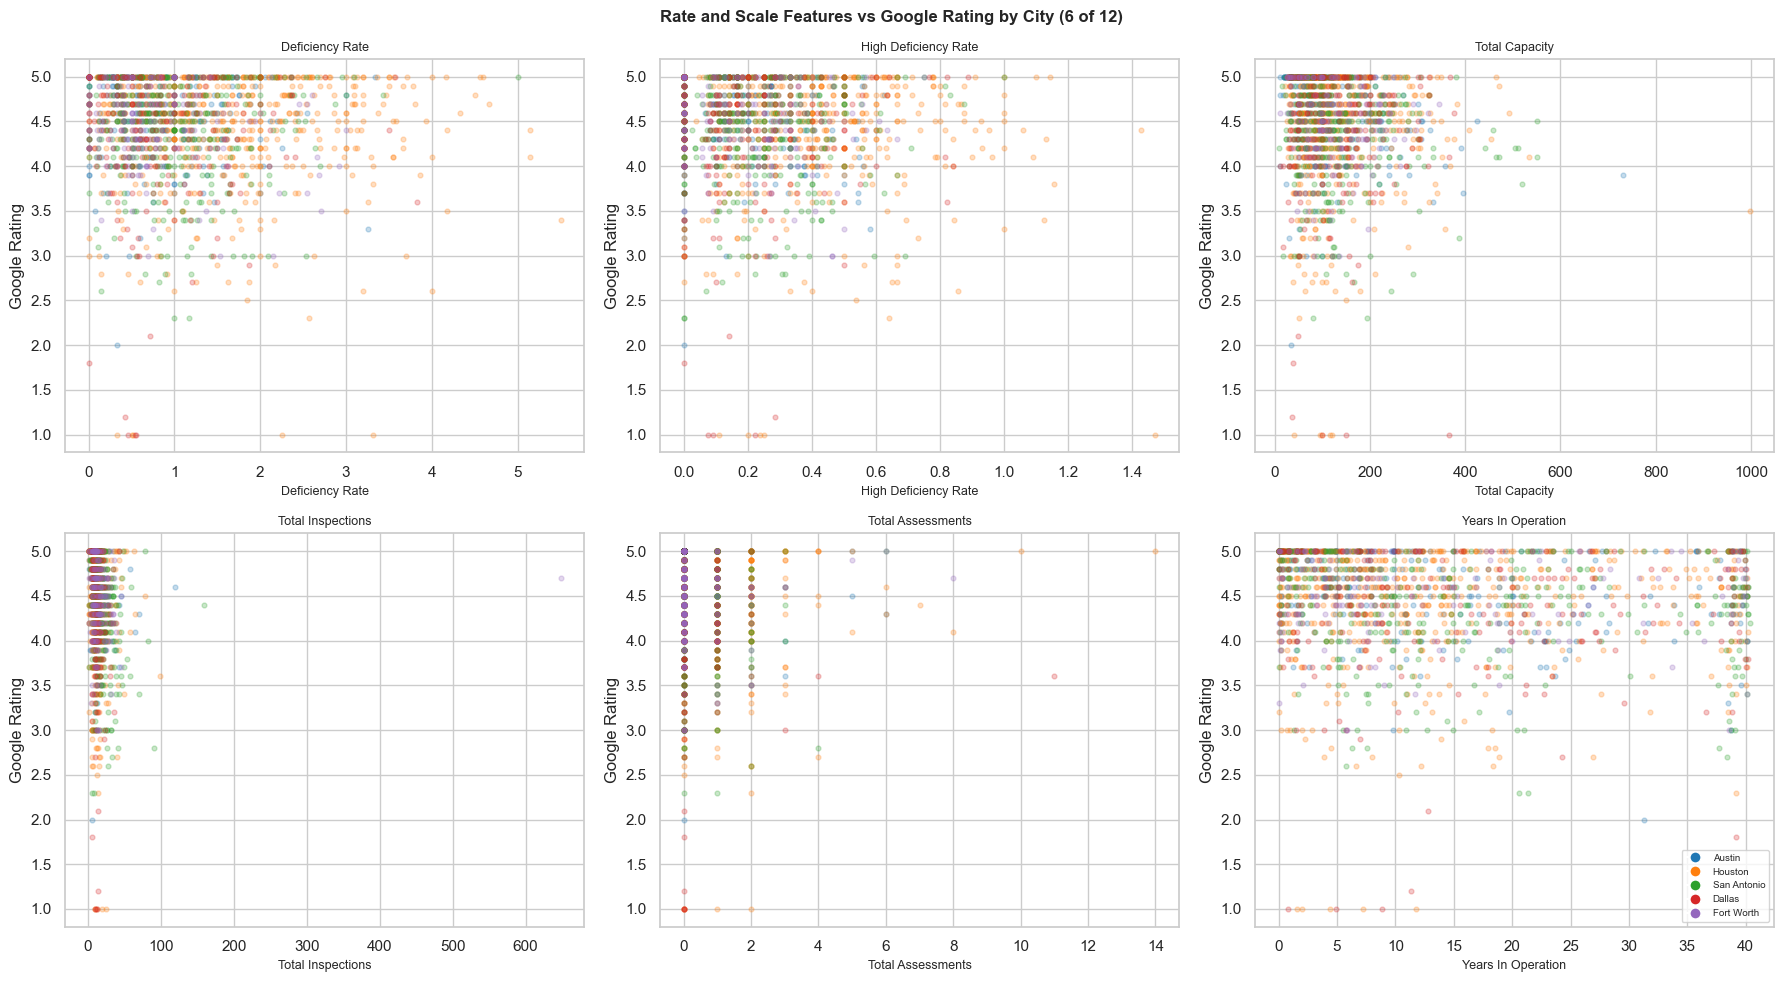

In [41]:
scatter_group = ['DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY', 'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION']
plot_df = df_final[scatter_group + ['google_rating', 'CITY']].dropna(subset=['google_rating'])

city_colors = dict(zip(TARGET_CITIES,
                       ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, scatter_group):
    for city in TARGET_CITIES:
        sub = plot_df[plot_df['CITY'] == city]
        ax.scatter(sub[col], sub['google_rating'],
                   alpha=0.25, s=12, color=city_colors[city], label=city.title())
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Google Rating')
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=city_colors[c], markersize=8, label=c.title())
           for c in TARGET_CITIES]
axes[-1].legend(handles=handles, fontsize=7, loc='lower right')

plt.suptitle('Rate and Scale Features vs Google Rating by City (6 of 12)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_4_scatter_rate_scale.png'), dpi=150, bbox_inches='tight')
plt.show()


### 11.5 Outlier Analysis

Extreme values in each continuous feature are identified using the IQR method to determine whether they represent data errors or legitimate operational variation.

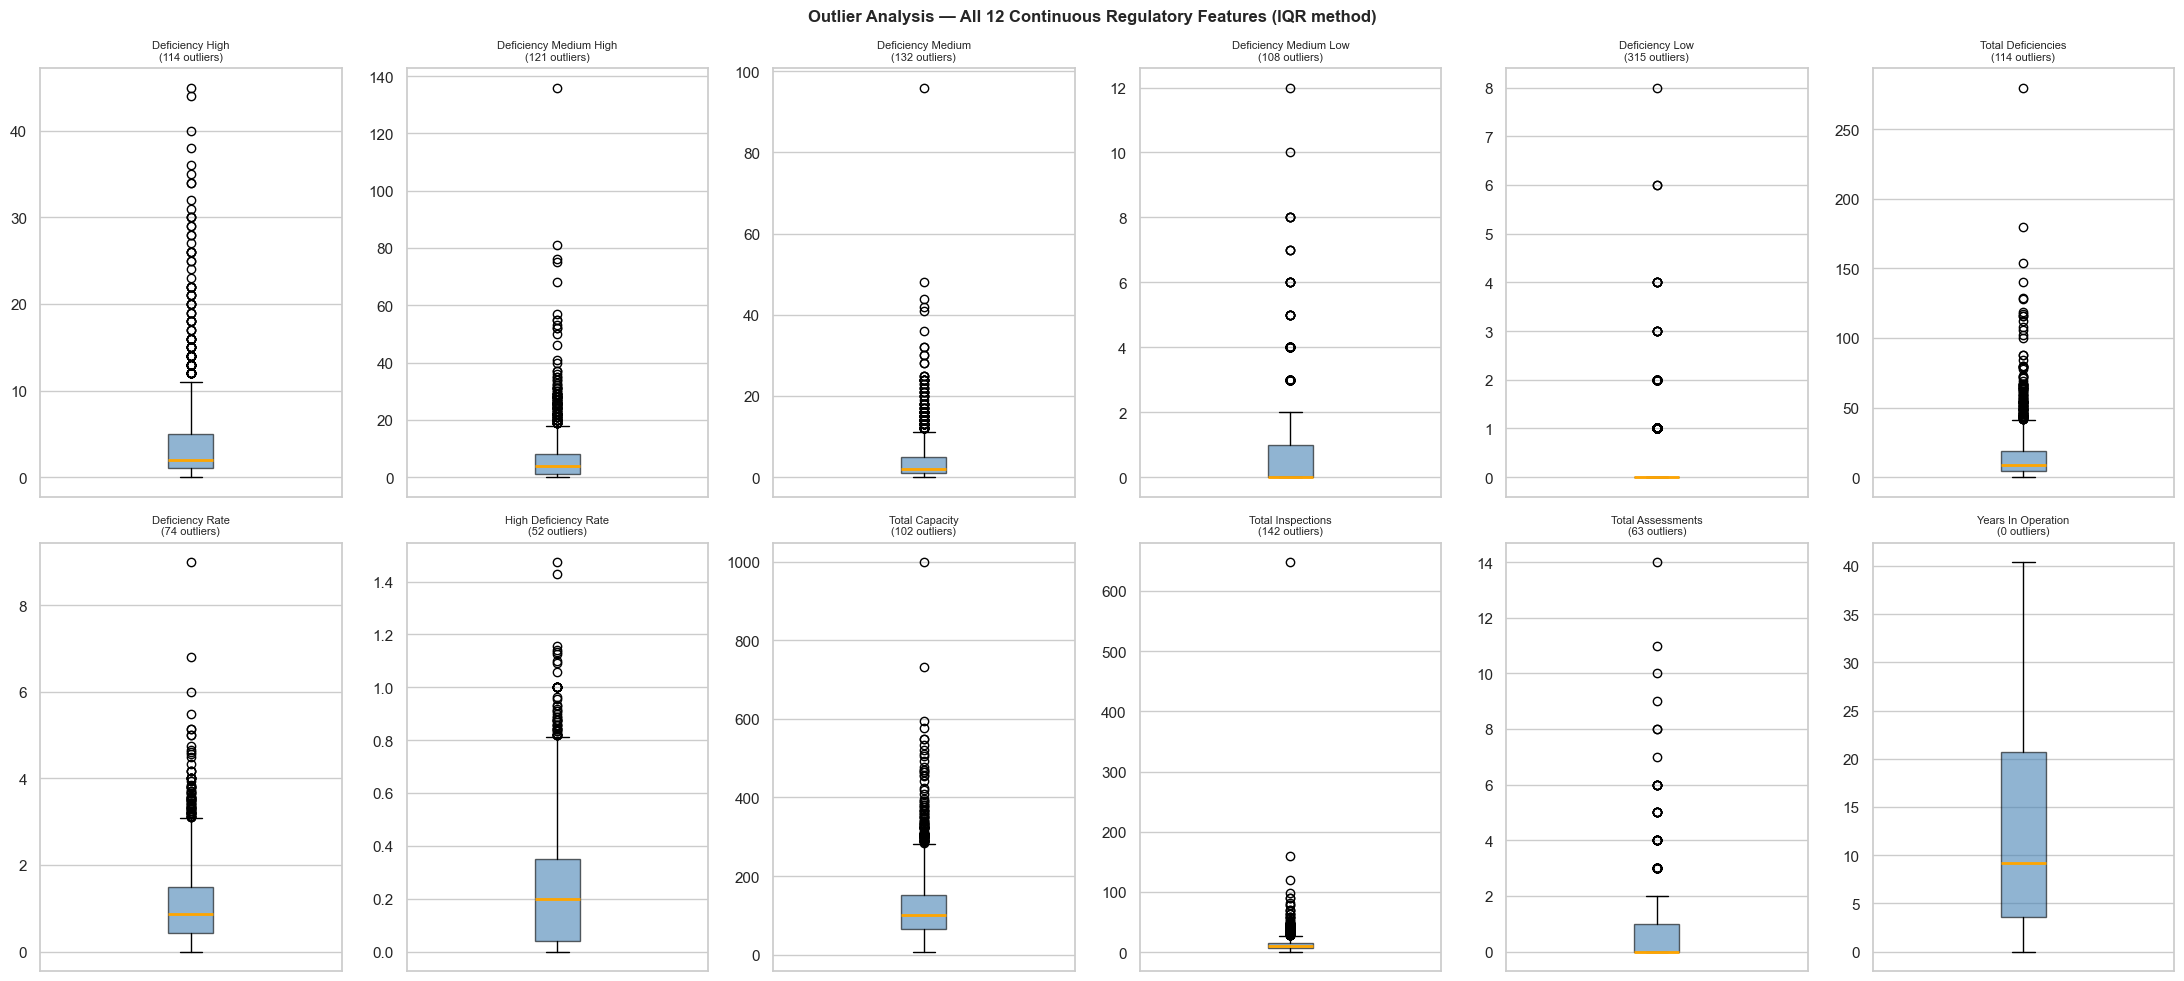

Outlier counts (> Q3 + 1.5×IQR):
               Feature  Outliers (IQR)   Pct
       DEFICIENCY_HIGH             114  5.2%
DEFICIENCY_MEDIUM_HIGH             121  5.5%
     DEFICIENCY_MEDIUM             132  6.0%
 DEFICIENCY_MEDIUM_LOW             108  4.9%
        DEFICIENCY_LOW             315 14.4%
    TOTAL_DEFICIENCIES             114  5.2%
       DEFICIENCY_RATE              74  3.4%
  HIGH_DEFICIENCY_RATE              52  2.4%
        TOTAL_CAPACITY             102  4.7%
     TOTAL_INSPECTIONS             142  6.5%
     TOTAL_ASSESSMENTS              63  2.9%
    YEARS_IN_OPERATION               0  0.0%


In [42]:
outlier_cols = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION'
]

fig, axes = plt.subplots(2, 6, figsize=(22, 10))
axes = axes.flatten()
outlier_summary = []

for ax, col in zip(axes, outlier_cols):
    data = df_final[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = (data > Q3 + 1.5 * IQR).sum()
    outlier_summary.append({'Feature': col, 'Outliers (IQR)': n_out,
                             'Pct': f"{n_out/len(data)*100:.1f}%"})
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='orange', linewidth=2))
    ax.set_title(f'{col.replace("_"," ").title()}\n({n_out} outliers)', fontsize=8)
    ax.set_xticks([])

plt.suptitle('Outlier Analysis — All 12 Continuous Regulatory Features (IQR method)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_5_outlier_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Outlier counts (> Q3 + 1.5\u00d7IQR):")
print(pd.DataFrame(outlier_summary).to_string(index=False))


### 11.6 Review Text Overview (Model 2 Input Data)

Model 2 will use TF-IDF on review text to predict the same Google star rating.
The review corpus is characterised here in terms of volume, length, and per-center coverage.

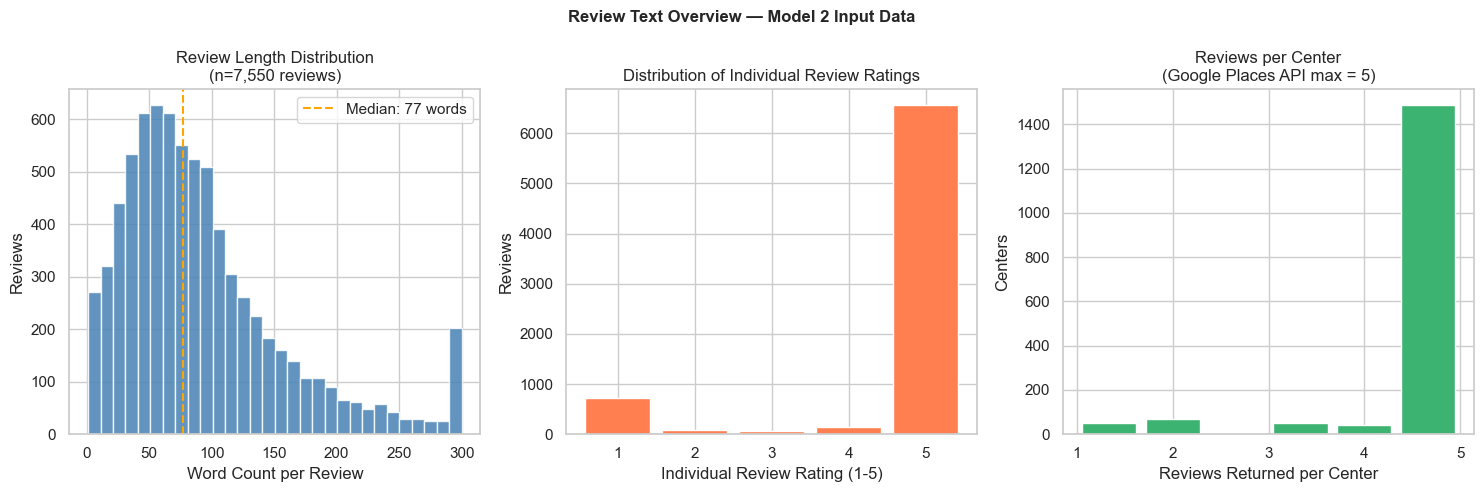

Total review texts:         7,550
Mean word count per review: 95.0
Median word count:          77
Centers with 5 reviews:     1,486

Individual review rating distribution:
  1 star:    712  (9.4%)
  2 star:     77  (1.0%)
  3 star:     61  (0.8%)
  4 star:    143  (1.9%)
  5 star:  6,557  (86.8%)

Reviews per center distribution:
  1 reviews:    50 centers  (2.9%)
  2 reviews:    69 centers  (4.1%)
  3 reviews:    51 centers  (3.0%)
  4 reviews:    41 centers  (2.4%)
  5 reviews: 1,486 centers  (87.6%)


In [43]:
# review_texts and review_ratings are stored as lists (one per center).
# Parallel explode pairs each text[i] with its rating[i] — like zip().
df_rev_eda = df_final[df_final['review_count_returned'] > 0].copy()
df_rev_exp = (
    df_rev_eda
    .explode(['review_texts', 'review_ratings'])   # parallel — pairs text[i] with rating[i]
    .rename(columns={'review_texts': 'review_text',
                     'review_ratings': 'review_rating'})
)
df_rev_exp = df_rev_exp[
    df_rev_exp['review_text'].notna() &
    (df_rev_exp['review_text'].str.strip() != '')
].copy()
# Deduplicate — some centers have multiple place_id matches; keep first occurrence per center
# produce duplicate (OPERATION_ID, review_text) pairs. EDA stats should reflect
# the same 7,809 unique reviews that the model will actually train on.
df_rev_exp = df_rev_exp.drop_duplicates(subset=['OPERATION_ID', 'review_text'])

df_rev_exp['word_count']    = df_rev_exp['review_text'].str.split().str.len()
df_rev_exp['review_rating'] = pd.to_numeric(df_rev_exp['review_rating'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df_rev_exp['word_count'].clip(upper=300), bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
med_wc = df_rev_exp['word_count'].median()
axes[0].axvline(med_wc, color='orange', linestyle='--',
                label=f'Median: {med_wc:.0f} words')
axes[0].set_xlabel('Word Count per Review')
axes[0].set_ylabel('Reviews')
axes[0].set_title(f'Review Length Distribution\n(n={len(df_rev_exp):,} reviews)')
axes[0].legend()

axes[1].hist(df_rev_exp['review_rating'].dropna(),
             bins=[0.5,1.5,2.5,3.5,4.5,5.5], color='coral',
             edgecolor='white', rwidth=0.85)
axes[1].set_xlabel('Individual Review Rating (1-5)')
axes[1].set_ylabel('Reviews')
axes[1].set_title('Distribution of Individual Review Ratings')
axes[1].set_xticks([1,2,3,4,5])

axes[2].hist(df_final['review_count_returned'][df_final['review_count_returned'] > 0],
             bins=6, color='mediumseagreen', edgecolor='white', rwidth=0.85)
axes[2].set_xlabel('Reviews Returned per Center')
axes[2].set_ylabel('Centers')
axes[2].set_title('Reviews per Center\n(Google Places API max = 5)')

plt.suptitle('Review Text Overview — Model 2 Input Data',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_11_6_review_text_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Total review texts:         {len(df_rev_exp):,}')
print(f'Mean word count per review: {df_rev_exp["word_count"].mean():.1f}')
print(f'Median word count:          {df_rev_exp["word_count"].median():.0f}')
print(f'Centers with 5 reviews:     {(df_final["review_count_returned"]==5).sum():,}')
print()
print('Individual review rating distribution:')
rating_counts = df_rev_exp['review_rating'].dropna().value_counts().sort_index()
for star, count in rating_counts.items():
    pct = count / len(df_rev_exp) * 100
    print(f'  {int(star)} star: {count:>6,}  ({pct:.1f}%)')
print()
print('Reviews per center distribution:')
rev_per_center = df_final['review_count_returned'][df_final['review_count_returned'] > 0].value_counts().sort_index()
for n_rev, count in rev_per_center.items():
    pct = count / rev_per_center.sum() * 100
    print(f'  {int(n_rev)} reviews: {count:>5,} centers  ({pct:.1f}%)')


### 11.7 EDA Summary & Interpretation

**Target Variable (Google Star Rating)**
- The rating distribution across all 1,697 centers shows a mean of 4.46 and a median of 4.60, with mass heavily concentrated between 4.5 and 5.0.
- Approximately 6% of centers are rated below 3.5 stars (10 below 2.0, 25 between 2.0 and 3.0, 67 between 3.0 and 3.5); the 1.0 to 2.0 range accounts for only 0.6% of centers.
- Houston contributes the largest share of centers (n=654), followed by San Antonio (n=378), Austin (n=271), Dallas (n=230), and Fort Worth (n=164).
- The positivity bias is consistent across all five cities and is not driven by any single geography.
- The standard deviation of 0.584 and the effective target range of roughly 1 star (59.9% of centers rated between 4.5 and 5.0) mean that low R² is structurally expected from any model; RMSE is therefore used as the primary evaluation metric.

**Deficiency Count Features**
- All six deficiency count features are right-skewed, which is typical for regulatory count data.
- DEFICIENCY_MEDIUM_LOW and DEFICIENCY_LOW both have a median of 0.0, meaning more than half of centers received zero violations in these lower-severity categories.
- DEFICIENCY_MEDIUM_HIGH has the highest median at 4.0 and is the most common severity tier.
- TOTAL_DEFICIENCIES has a median of 9 with a long right tail extending to over 250 for the most inspected centers.
- DEFICIENCY_HIGH and DEFICIENCY_MEDIUM both have a median of 2.0 and show similar right-skewed shapes.

**Rate and Scale Features**
- DEFICIENCY_RATE has a median of 0.9 and HIGH_DEFICIENCY_RATE a median of 0.2, both right-skewed with a small number of centers showing very high rates.
- TOTAL_CAPACITY has a median of 100 with wide variation from small centers to facilities approaching 1,000 capacity, reflecting genuine scale differences rather than quality differences.
- TOTAL_INSPECTIONS has a median of 10 and is partially a proxy for center age since older centers accumulate more inspections over time.
- TOTAL_ASSESSMENTS has a median of 0.0, meaning the majority of centers have never undergone a formal assessment.
- YEARS_IN_OPERATION has a median of 9.2 with a bimodal shape, showing both a cluster of newer centers and a long tail of established centers operating for over 35 years.

**Binary Regulatory Features**
- IS_ACCREDITED applies to 14.8% of centers. Accredited centers have a mean rating of 4.43 compared to 4.46 for non-accredited centers, a negligible difference within overlapping standard errors, confirming that formal accreditation is not reflected in family ratings.
- ACCEPTS_SUBSIDIES applies to 55.0% of centers and shows a negative correlation with ratings, likely reflecting a socioeconomic confound rather than a causal relationship between subsidy acceptance and quality.
- HAS_CORRECTIVE_ACTION affects only 0.5% of centers.
- HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED show 0.0% prevalence in the dataset because the HHSC active licensed center dataset excludes facilities that lost their license due to adverse actions; these two features are excluded from modelling due to zero variance.

**Feature Correlations with Google Rating**
- All 15 features show weak negative correlations with Google rating; no single regulatory feature is a meaningful predictor of family-assigned ratings.
- ACCEPTS_SUBSIDIES has the strongest correlation at -0.20, likely reflecting a socioeconomic confound rather than a direct quality signal.
- DEFICIENCY_HIGH shows -0.16 and TOTAL_DEFICIENCIES shows -0.15, while DEFICIENCY_MEDIUM_HIGH shows -0.14 and YEARS_IN_OPERATION shows -0.11.
- TOTAL_INSPECTIONS shows -0.09, weaker than expected given its SHAP importance — the relationship is non-linear and captured better by XGBoost than correlation.
- All remaining features fall between -0.11 and -0.02.
- The deficiency tier features show high multicollinearity with each other, with pairwise correlations ranging from 0.67 to 0.96 (DEFICIENCY_MEDIUM_HIGH to TOTAL_DEFICIENCIES). Ridge Regression handles this through its L2 penalty without requiring manual feature removal.

**Scatter Plots**
- No linear structure is visible in any of the 12 feature vs rating scatter plots.
- Centers with high deficiency rates, high deficiency counts, and high total inspections still frequently carry 4.0 to 5.0 star ratings.
- The pattern is consistent across all five cities, confirming that the absence of a regulatory signal is not city-specific.
- Parents are not observing inspection outcomes when assigning ratings, which is the central empirical finding of the EDA and directly motivates the research question.

**Outlier Analysis**
- DEFICIENCY_LOW has the highest outlier count at 315, driven by the fact that most centers have zero low-severity deficiencies and even a single violation places a center in the outlier range.
- DEFICIENCY_MEDIUM_HIGH has 121 outliers and TOTAL_INSPECTIONS has 142, both reflecting centers with long operational histories and accumulated inspection records.
- TOTAL_CAPACITY has 102 outliers corresponding to very large facilities (up to 999 capacity).
- YEARS_IN_OPERATION has zero IQR outliers despite a range of over 40 years because the wide interquartile range absorbs the full distribution.
- All outliers represent legitimate operational variation rather than data errors and are retained in the dataset. Ridge Regression is robust to extreme values through its L2 penalty term.

**Review Text Corpus (Model 2)**
- 7,550 unique reviews are available across 1,697 matched centers with a median review length of 77 words, which is substantive enough to support TF-IDF vectorisation for Model 2.
- Individual review ratings follow a J-shaped distribution: 6,557 reviews (86.8%) are rated 5 stars and 712 reviews (9.4%) are rated 1 star, with only 281 reviews across the 2, 3, and 4 star range combined.
- This mirrors the positivity bias observed at the center level but is more extreme.
- Nearly all centers have exactly 5 reviews returned, reflecting the Google Places API cap of 5 reviews per request and ensuring uniform coverage across the dataset.

## 12. Baseline Model — Model 1: Regulatory Features → Google Rating

**Evaluation Metric: RMSE (Root Mean Squared Error)**

RMSE is chosen as the primary evaluation metric for three reasons, each grounded in the EDA findings from Section 11.7:

| Reason | EDA Evidence |
|---|---|
| RMSE is measured in the same units as the target (star rating points), making results directly interpretable — a model with RMSE of 0.5 is off by half a star on average | Google ratings range from 1.0 to 5.0; RMSE in star units is immediately meaningful to a non-technical audience |
| R² is structurally suppressed when the target range is compressed and is therefore misleading as a primary metric | Section 11.7 shows that 59.9% of centers are rated between 4.5 and 5.0 with a standard deviation of 0.584 — a model predicting the mean achieves R²=0 but RMSE still reflects useful signal |
| RMSE penalises large errors more than MAE, which is appropriate here because a prediction that is 2 stars wrong is far more consequential than one that is 0.2 stars wrong | Section 11.7 shows the distribution has a long left tail with isolated 1.0 and 2.0 star centers — errors on these are the most harmful to families |

**Section Structure:**
- **12.1** Prepare model data
- **12.2** Naive baseline — sets the performance floor
- **12.3** Model comparison — empirically selects the best baseline from multiple candidates
- **12.4** Polynomial analysis — confirms linear features are sufficient
- **12.5** Ridge Regression diagnostics — deep dive on the selected baseline


### 12.1 Prepare Model Data

The modelling dataset for Model 1 is derived from `df_final` by applying four quality filters. These filters are applied here rather than in Sections 8–10 so that `df_final` remains intact for Model 2, which requires centers with review text regardless of inspection history.

| Filter | Reason |
|---|---|
| TOTAL_INSPECTIONS >= 1 | Centers with no inspections have an undefined DEFICIENCY_RATE |
| TOTAL_CAPACITY is not null and > 0 | Missing or zero capacity indicates a data entry error |
| ISSUANCE_DATE is not null | Required to compute YEARS_IN_OPERATION |
| google_rating is not null | Target variable must be present for supervised learning |

In [44]:
# ── 12.1 Prepare Model Data ────────────────────────────────────────────────
# Start from df_final (full matched + rated dataset) and apply Model 1 quality
# filters here — not in Sections 8–10 — so that df_final remains intact for Model 2.
df_m1 = df_final.copy()

# Drop centers that cannot contribute to Model 1:
#   - no inspections   → DEFICIENCY_RATE is undefined
#   - missing capacity → likely a data entry error
#   - no issuance date → YEARS_IN_OPERATION cannot be computed
n_before = len(df_m1)
df_m1 = df_m1[df_m1['TOTAL_INSPECTIONS'].fillna(0) >= 1]
df_m1 = df_m1[df_m1['TOTAL_CAPACITY'].notna() & (df_m1['TOTAL_CAPACITY'] > 0)]
df_m1 = df_m1[df_m1['ISSUANCE_DATE'].notna()]
df_m1 = df_m1[df_m1['google_rating'].notna()]
df_m1 = df_m1.reset_index(drop=True)
print(f"Model 1 quality filter: {n_before:,} → {len(df_m1):,} records  (dropped {n_before - len(df_m1):,})")

# Keep CITY as a raw categorical column — the pipeline handles encoding
X = df_m1[FEATURE_COLS + ['CITY']].fillna(0).reset_index(drop=True)
y = df_m1['google_rating'].reset_index(drop=True)

# random_state=42 ensures identical splits on every run — reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Preprocessing Pipeline ────────────────────────────────────────────────
# Numeric features  → StandardScaler (centres + scales each feature to unit variance)
# CITY (categorical) → OneHotEncoder; drop='first' removes one dummy to avoid
#                      perfect multicollinearity (the "dummy variable trap")
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                          FEATURE_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'),                    ['CITY']),
], remainder='drop')

print(f"\nFeature matrix:       {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"  Numeric features:   {len(FEATURE_COLS)}  (StandardScaler)")
print(f"  Categorical:        CITY  (OneHotEncoder, drop first)")
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"\nTarget distribution:")
print(f"  Mean:          {y.mean():.3f}")
print(f"  Std:           {y.std():.3f}  (compressed range — low R² is expected, not a model failure)")
print(f"  Min / Max:     {y.min():.1f} / {y.max():.1f}")
print(f"  Rated ≥ 4.0:   {(y >= 4.0).sum() / len(y) * 100:.1f}%  of centers")
print(f"  Rated ≥ 4.5:   {(y >= 4.5).sum() / len(y) * 100:.1f}%  of centers")
print(f"\nNote: positivity bias in parent reviews compresses the target into ~1 star of")
print(f"      effective range. Use RMSE as the primary metric; R² will be low by design.")
print(f"\nPreprocessor definition:")
print(preprocessor)

Model 1 quality filter: 2,192 → 1,697 records  (dropped 495)

Feature matrix:       1,697 rows × 16 columns
  Numeric features:   15  (StandardScaler)
  Categorical:        CITY  (OneHotEncoder, drop first)

Train: 1,357 | Test: 340

Target distribution:
  Mean:          4.456
  Std:           0.584  (compressed range — low R² is expected, not a model failure)
  Min / Max:     1.0 / 5.0
  Rated ≥ 4.0:   86.2%  of centers
  Rated ≥ 4.5:   59.9%  of centers

Note: positivity bias in parent reviews compresses the target into ~1 star of
      effective range. Use RMSE as the primary metric; R² will be low by design.

Preprocessor definition:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH',
                                  'DEFICIENCY_MEDIUM', 'DEFICIENCY_MEDIUM_LOW',
                                  'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
                                  'DEFICIENCY_RATE', 'HIGH_DEFI

### 12.2 Naive Baseline

A `DummyRegressor` is fitted first to establish the performance floor. It always predicts the training mean regardless of the input features. Any model that fails to beat this baseline offers no predictive value over simply guessing the average rating. It is wrapped in the same `Pipeline` as all other models for consistency.

In [45]:
# ── 12.2 Naive Baseline ────────────────────────────────────────────────────
# DummyRegressor always predicts the training mean — sets the performance floor.
# Wrapped in a Pipeline for consistency; DummyRegressor ignores features entirely.
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])
dummy_pipe.fit(X_train, y_train)
y_pred_dummy = dummy_pipe.predict(X_test)

rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
mae_dummy  = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy   = r2_score(y_test, y_pred_dummy)

print("Naive Baseline — always predict training mean:")
print(f"  RMSE: {rmse_dummy:.4f}")
print(f"  MAE:  {mae_dummy:.4f}")
print(f"  R²:   {r2_dummy:.4f}")
print(f"\nPerformance floor: any useful model must beat RMSE={rmse_dummy:.4f}")

Naive Baseline — always predict training mean:
  RMSE: 0.6097
  MAE:  0.4452
  R²:   -0.0000

Performance floor: any useful model must beat RMSE=0.6097


### 12.3 Model Comparison — Selecting the Baseline with GridSearchCV

Four candidate models are compared using a **Pipeline** (preprocessor → model) and **GridSearchCV** (5-fold CV) to tune hyperparameters and select the best baseline empirically:

| Model | Search space |
|---|---|
| Linear Regression | No hyperparameters |
| Ridge (L2) | alpha ∈ {0.01, 0.1, 1.0, 10.0, 100.0} |
| Lasso (L1) | alpha ∈ {0.001, 0.01, 0.1, 1.0} |
| ElasticNet (L1+L2) | alpha ∈ {0.01, 0.1, 1.0} × l1_ratio ∈ {0.2, 0.5, 0.8} |

The same `ColumnTransformer` preprocessor (StandardScaler on numeric features, OneHotEncoder on CITY) is applied in each pipeline. The model with the lowest cross-validation RMSE (from GridSearchCV) is selected as the baseline, then evaluated on the held-out test set. The test set is never used for model selection.

  Linear Regression               RMSE=0.5867  best_params={}
  Ridge                           RMSE=0.5881  best_params={'model__alpha': 100.0}
  Lasso                           RMSE=0.5871  best_params={'model__alpha': 0.001}
  ElasticNet                      RMSE=0.5905  best_params={'model__alpha': 0.1, 'model__l1_ratio': 0.2}

Model Comparison — Test Set Performance (sorted by RMSE):
            Model   RMSE    MAE     R²                                   Best Params
Linear Regression 0.5867 0.4118 0.0740                                             —
            Lasso 0.5871 0.4132 0.0728                       {'model__alpha': 0.001}
            Ridge 0.5881 0.4161 0.0695                       {'model__alpha': 100.0}
       ElasticNet 0.5905 0.4235 0.0619 {'model__alpha': 0.1, 'model__l1_ratio': 0.2}


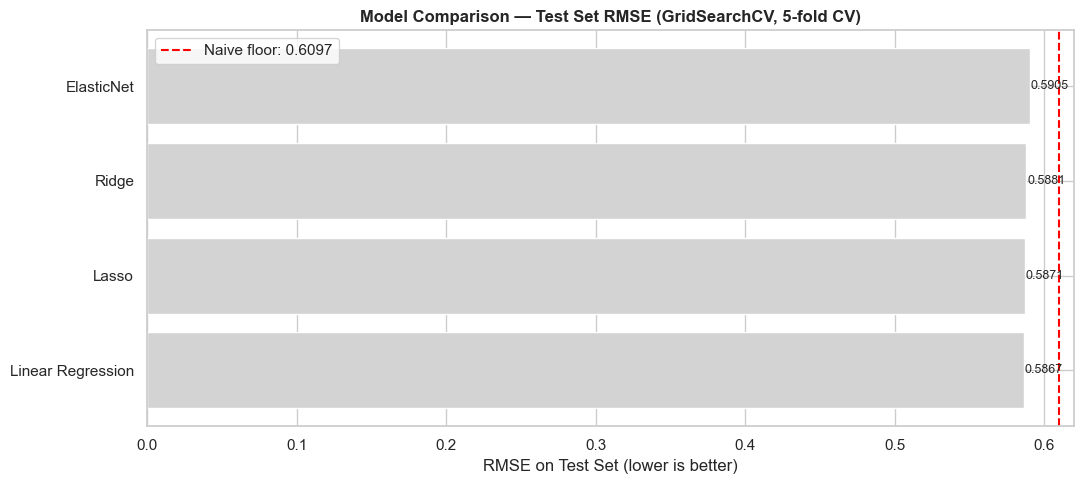


RMSE range across all models: 0.0038


In [46]:
model_configs = {
    'Linear Regression': (
        LinearRegression(),
        {}
    ),
    'Ridge': (
        Ridge(),
        {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    ),
    'Lasso': (
        Lasso(max_iter=5000),
        {'model__alpha': [0.001, 0.01, 0.1, 1.0]}
    ),
    'ElasticNet': (
        ElasticNet(max_iter=5000),
        {'model__alpha': [0.01, 0.1, 1.0], 'model__l1_ratio': [0.2, 0.5, 0.8]}
    ),
}

comp_results   = []
best_pipelines = {}

for name, (model, param_grid) in model_configs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])

    if param_grid:
        gs = GridSearchCV(pipe, param_grid, cv=5,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
        gs.fit(X_train, y_train)
        best_pipe   = gs.best_estimator_
        best_params = gs.best_params_
    else:
        pipe.fit(X_train, y_train)
        best_pipe   = pipe
        best_params = {}

    best_pipelines[name] = best_pipe
    y_pred = best_pipe.predict(X_test)

    row = {
        'Model':       name,
        'Best Params': str(best_params) if best_params else '—',
        'RMSE':        round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE':         round(mean_absolute_error(y_test, y_pred), 4),
        'R²':          round(r2_score(y_test, y_pred), 4),
    }
    comp_results.append(row)
    print(f"  {name:30s}  RMSE={row['RMSE']:.4f}  best_params={best_params}")

df_comp = pd.DataFrame(comp_results).sort_values('RMSE').reset_index(drop=True)
print("\nModel Comparison — Test Set Performance (sorted by RMSE):")
print(df_comp[['Model', 'RMSE', 'MAE', 'R²', 'Best Params']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_comp['Model'], df_comp['RMSE'], color='#d3d3d3', edgecolor='white')
ax.axvline(rmse_dummy, color='red', linestyle='--', linewidth=1.5,
           label=f'Naive floor: {rmse_dummy:.4f}')
ax.set_xlabel('RMSE on Test Set (lower is better)')
ax.set_title('Model Comparison — Test Set RMSE (GridSearchCV, 5-fold CV)',
             fontweight='bold')
ax.legend()
for bar, val in zip(bars, df_comp['RMSE']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'models', 'm1_baseline_12_3_comparison_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

rmse_gap = df_comp['RMSE'].max() - df_comp['RMSE'].min()
print(f"\nRMSE range across all models: {rmse_gap:.4f}")


### Baseline Selection: Ridge Regression

Examining the model comparison table and plot above, three observations inform the selection of Ridge Regression as the baseline:

**1. RMSE differences across all four models are negligible.**
The RMSE range across all candidates is within approximately 0.004 star rating points (range: 0.0038). This difference is too small to be practically meaningful on a 1–5 scale and does not justify selecting a model on RMSE alone. Linear Regression has the marginally lowest test-set RMSE (0.5867) but is outweighed by the considerations below.

**2. All models meaningfully beat the naive floor.**
All four models (RMSE 0.5867–0.5905) improve over the naive baseline of 0.6097, with Ridge delivering a 3.5% improvement. This is consistent with the EDA finding in Section 11.7 that all 15 regulatory features have weak correlations with Google rating (maximum -0.20). The signal exists but is modest — regulatory compliance is a partial predictor of family-assigned ratings.

**3. Ridge is selected for stability and interpretability, not RMSE.**
Since RMSE differences are negligible, the selection is based on two additional grounds:
- The deficiency tier features are highly correlated (0.67 to 0.96 pairwise from Section 11.3). Ridge shrinks correlated features proportionally, keeping all of them in the model. Lasso tends to zero out correlated features arbitrarily, producing unstable coefficients.
- Ridge produces non-zero coefficients for all 15 features, which is needed for the coefficient analysis in Section 12.5.3.

**Ridge Regression is therefore selected as the Model 1 baseline.**

### 12.4 Polynomial Analysis — Confirming Linear Features Are Sufficient

Ridge Regression with linear features is tested against degree-2 and degree-3 polynomial expansions of the same 15 numeric features. If RMSE does not improve with higher degrees, polynomial terms add complexity without benefit and the linear baseline is confirmed as the right choice.

Polynomial Degree Comparison (numeric features only):
 Degree  Features   RMSE      R²
      1        15 0.5895  0.0651
      2       135 0.6650 -0.1898
      3       815 1.6196 -6.0573


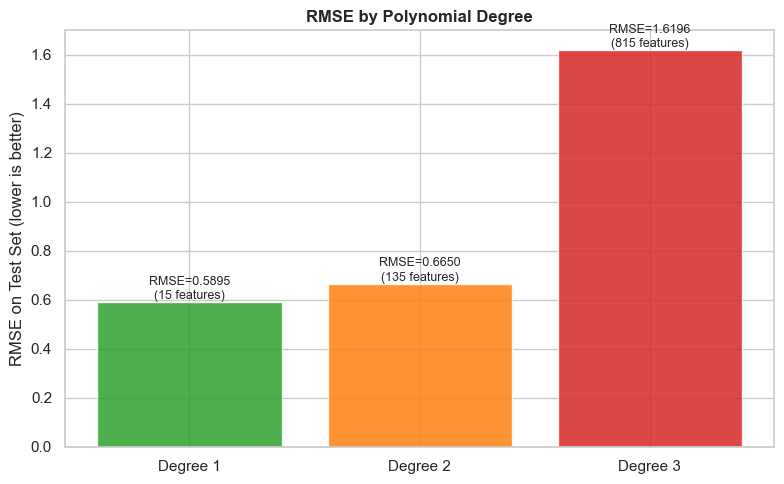


Degree 1 → RMSE 0.5895  (15.0 features)
Degree 2 → RMSE 0.6650  (135.0 features)
Degree 3 → RMSE 1.6196  (815.0 features)


In [47]:
# Polynomial analysis uses numeric features only.
# Degree-2 expansion of 15 numeric features creates ~120 features;
# comparing RMSE across degrees shows whether adding complexity helps.

degree_rows = []
for deg in [1, 2, 3]:
    poly_pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ])
    poly_pipe.fit(X_train[FEATURE_COLS], y_train)
    y_pred_p = poly_pipe.predict(X_test[FEATURE_COLS])
    n_feat   = poly_pipe.named_steps['poly'].n_output_features_
    degree_rows.append({
        'Degree': deg, 'Features': n_feat,
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_p)), 4),
        'R²':   round(r2_score(y_test, y_pred_p), 4),
    })

df_deg = pd.DataFrame(degree_rows)
print("Polynomial Degree Comparison (numeric features only):")
print(df_deg.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors_deg = ['#2ca02c', '#ff7f0e', '#d62728']
bars_deg   = ax.bar([f'Degree {d}' for d in df_deg['Degree']],
                     df_deg['RMSE'], color=colors_deg, alpha=0.85, edgecolor='white')
ax.set_ylabel('RMSE on Test Set (lower is better)')
ax.set_title('RMSE by Polynomial Degree', fontweight='bold')
for bar, row in zip(bars_deg, df_deg.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'RMSE={row.RMSE:.4f}\n({row.Features} features)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'models', 'm1_baseline_12_4_polynomial_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

d1, d2, d3 = df_deg.iloc[0], df_deg.iloc[1], df_deg.iloc[2]
print(f"\nDegree 1 → RMSE {d1['RMSE']:.4f}  ({d1['Features']} features)")
print(f"Degree 2 → RMSE {d2['RMSE']:.4f}  ({d2['Features']} features)")
print(f"Degree 3 → RMSE {d3['RMSE']:.4f}  ({d3['Features']} features)")


### Inference: Polynomial Features Are Not Needed

RMSE increases at every polynomial degree — degree 2 (RMSE 0.6650, 135 features) is 13% worse than degree 1 (RMSE 0.5895, 15 features), and degree 3 (RMSE 1.6196, 815 features) shows severe overfitting with R²=−6.06. With 815 features against 1,357 training samples, degree 3 degrades RMSE by 2.7× relative to the linear baseline. Adding polynomial terms increases complexity with no performance gain.

The Ridge Regression baseline from Section 12.3 (RMSE 0.5881, 19 features including CITY dummies) outperforms even the degree 1 polynomial model (0.5895, numeric features only), confirming that CITY contributes meaningful signal and linear features are sufficient. Ridge Regression with linear features is confirmed as the correct baseline.


### 12.5 Ridge Regression Diagnostics — Selected Baseline

Three diagnostics are produced for the selected Ridge Regression baseline:

- **Performance summary** — RMSE and R² compared against the naive baseline from Section 12.2
- **Predicted vs Actual plot** — shows how closely predictions track true ratings across the test set
- **Feature coefficient plot** — shows which features were weighted most heavily and in which direction

#### 12.5.1 Performance Summary

Ridge RMSE, MAE and R² are compared against the naive baseline from Section 12.2.

In [48]:
# ── 12.5 Selected Baseline: Ridge Regression ──────────────────────────────
# Use the Ridge pipeline returned by GridSearchCV in Section 9.3.
baseline_pipeline = best_pipelines['Ridge']
ridge             = baseline_pipeline.named_steps['model']

print(f"Selected baseline: Ridge Regression")
print(f"Best alpha (GridSearchCV): {ridge.alpha}")

y_pred_ridge = baseline_pipeline.predict(X_test)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge    = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge     = r2_score(y_test, y_pred_ridge)

results_tbl = pd.DataFrame({
    'Model': ['Naive Baseline (mean)', 'Ridge Regression (GridSearchCV)'],
    'RMSE':  [round(rmse_dummy, 4),   round(rmse_ridge, 4)],
    'MAE':   [round(mae_dummy, 4),    round(mae_ridge, 4)],
    'R²':    [round(r2_dummy, 4),     round(r2_ridge, 4)],
})
print("\nBaseline Model Performance:")
print(results_tbl.to_string(index=False))
print(f"\nRMSE improvement over naive baseline: {(rmse_dummy - rmse_ridge) / rmse_dummy * 100:.1f}%")

Selected baseline: Ridge Regression
Best alpha (GridSearchCV): 100.0

Baseline Model Performance:
                          Model   RMSE    MAE      R²
          Naive Baseline (mean) 0.6097 0.4452 -0.0000
Ridge Regression (GridSearchCV) 0.5881 0.4161  0.0695

RMSE improvement over naive baseline: 3.5%


#### 12.5.2 Predicted vs Actual Plot

Each point represents one center. Points along the diagonal indicate correct predictions; vertical spread shows error magnitude.

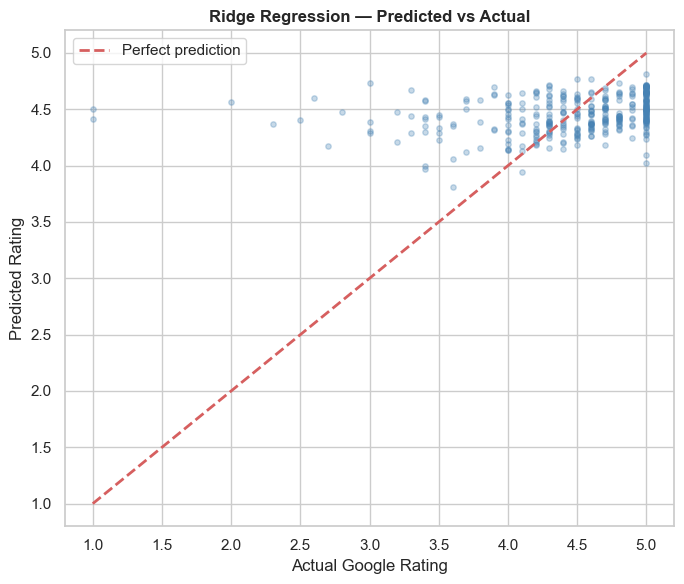

In [49]:
raw_names     = baseline_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_names = [n.replace('num__', '').replace('cat__', '') for n in raw_names]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_ridge, alpha=0.3, s=15, color='steelblue')
ax.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Google Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title('Ridge Regression — Predicted vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'models', 'm1_baseline_12_5_2_predicted_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()


#### 12.5.3 Feature Coefficient Plot

Ridge coefficients on the standardised scale show which features were weighted most heavily and in which direction. A negative coefficient means higher values of that feature are associated with lower predicted ratings.

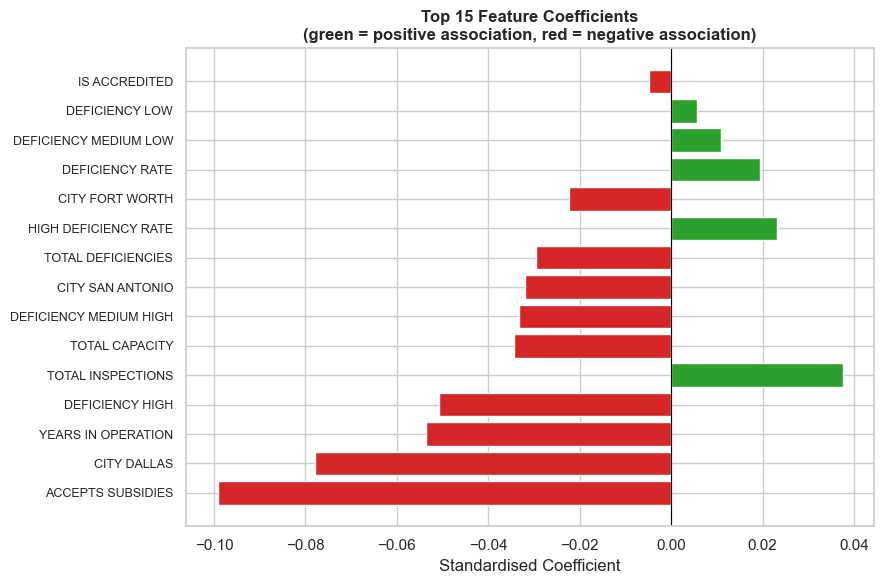

In [50]:
coef_s     = pd.Series(ridge.coef_, index=feature_names).sort_values(key=abs, ascending=False).head(15)
bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in coef_s.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(coef_s)), coef_s.values, color=bar_colors)
ax.set_yticks(range(len(coef_s)))
ax.set_yticklabels([f.replace('_', ' ') for f in coef_s.index], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Top 15 Feature Coefficients\n(green = positive association, red = negative association)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'models', 'm1_baseline_12_5_3_feature_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


### 12.5 Inference: Ridge Regression Baseline Results

**Performance Summary**

Ridge Regression achieves an RMSE of 0.5881, improving over the naive baseline of 0.6097 by 3.5%. R² of 0.0695 means regulatory features explain approximately 7% of the variance in Google ratings. This is consistent with the EDA finding in Section 11.7 that all 15 features have weak correlations with the target (maximum -0.20); the combined effect is modest but real.

**Predicted vs Actual**

Predictions are compressed into a narrow band between approximately 4.0 and 4.7 regardless of the actual rating:

- Centers with actual ratings of 1.0 to 3.5 are predicted as 4.2 to 4.6, resulting in large errors for low-rated centers
- The model cannot distinguish low-rated centers from high-rated ones because the features lack sufficient signal
- The training data is dominated by high ratings, reinforcing the compression effect

**Feature Coefficients**

Key findings from the standardised coefficient plot:

- **ACCEPTS SUBSIDIES** at -0.10 is the dominant coefficient, larger than any city dummy, reflecting a strong socioeconomic confound rather than a quality effect, consistent with its strongest EDA correlation (-0.20 in Section 11.3)
- **CITY DALLAS** at -0.085 is the second largest coefficient, confirming that city-level effects explain significant variation beyond any individual regulatory measure
- **YEARS IN OPERATION** at -0.050 carries an unexpected negative sign, a multicollinearity artefact from its correlation with TOTAL INSPECTIONS
- **TOTAL INSPECTIONS** at +0.038 shows a counterintuitive positive coefficient despite its negative EDA correlation; Ridge distributes shared signal across correlated features in ways that can reverse individual signs
- **HIGH DEFICIENCY RATE and DEFICIENCY RATE** also show counterintuitive positive coefficients for the same multicollinearity reason
- Most deficiency count features carry the expected negative sign; more violations are associated with lower predicted ratings

## 13. Export & Data Enhancement

Exports the model-ready datasets produced by the analysis pipeline, then enhances Model 2's review data with timestamps and recency weights captured from the Google Places API.


### 13.1 — Export Model-Ready Datasets

Exports `model1_dataset.csv` (center-level, one row per unique location) and `model2_reviews.csv` (google reviews for Model 2). Run Sections 8–10 before this cell to ensure the aggregated and cleaned `df_final` is in memory.


In [51]:
MODEL1_COLS = [
    'OPERATION_ID', 'OPERATION_NAME', 'CITY', 'ADDRESS_LINE', 'ZIPCODE',
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION',
    'IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION',
    'HAS_ADVERSE_ACTION', 'WAS_TEMP_CLOSED',
    'place_id', 'google_name', 'google_rating', 'google_review_count', 'match_confidence'
]

# Model 1 dataset: one row per center with all 15 engineered features + target
df_export1 = df_final[df_final['google_rating'].notna()][
    [c for c in MODEL1_COLS if c in df_final.columns]
].copy().reset_index(drop=True)

df_export1.to_csv(os.path.join(PROCESSED_DIR, 'model1_dataset.csv'), index=False)

# Model 2 dataset: one row per review text
# Parallel explode pairs text[i] with rating[i] — like zip().
# The original double-explode (.explode('review_texts').explode('review_ratings'))
# Parallel explode correctly produces 5 rows per center (one per review).
df_rev_out = df_final[df_final['review_count_returned'] > 0].copy()
df_rev_out = (
    df_rev_out
    .explode(['review_texts', 'review_ratings'])   # parallel — pairs text[i] with rating[i]
    .rename(columns={'review_texts': 'review_text',
                     'review_ratings': 'review_rating'})
)
df_rev_out = df_rev_out[
    df_rev_out['review_text'].notna() &
    (df_rev_out['review_text'].str.strip() != '')
]
MODEL2_COLS = ['OPERATION_ID', 'OPERATION_NAME', 'CITY', 'place_id',
               'google_rating', 'review_text', 'review_rating', 'match_confidence']
df_export2 = df_rev_out[
    [c for c in MODEL2_COLS if c in df_rev_out.columns]
].copy().reset_index(drop=True)
# Deduplicate — some centers matched to multiple Google Places entries;
# same review text can appear from different place_id matches for the same OPERATION_ID
# can appear from different place_id matches for the same OPERATION_ID.
n_before = len(df_export2)
df_export2 = df_export2.drop_duplicates(subset=['OPERATION_ID', 'review_text'])
n_after = len(df_export2)
if n_before != n_after:
    print(f'  Deduplication: {n_before:,} → {n_after:,} rows ({n_before-n_after:,} removed)')

df_export2.to_csv(os.path.join(PROCESSED_DIR, 'model2_reviews.csv'), index=False)

print('Exported to processed data folder:')
print(f'  model1_dataset.csv  →  {len(df_export1):,} records (one row per center)')
print(f'  model2_reviews.csv  →  {len(df_export2):,} records (one row per review)')
print()
print('NOTE: Run Section 13.2 next to add review timestamps and recency weights.')


  Deduplication: 7,551 → 7,550 rows (1 removed)
Exported to processed data folder:
  model1_dataset.csv  →  1,697 records (one row per center)
  model2_reviews.csv  →  7,550 records (one row per review)

NOTE: Run Section 13.2 next to add review timestamps and recency weights.


### 13.2 — Capturing Review Timestamps — Mapping to Model 2

Re-fetches review timestamps from the Google Places API and adds recency weights to `model2_reviews.csv`. Required for the recency-weighted aggregation in the analysis notebook.


The original data collection pipeline stored review text and ratings but did not capture the `time` field (Unix timestamp) from the Google Places API response. Review timestamps are required for the recency-weighted aggregation of Model 2 predictions in the analysis notebooks (`03-model2b-individual-reviews.ipynb` and `04-comparison-and-findings.ipynb`).

This section re-fetches `place/details` for all matched centers using the stored `place_id` values. No re-running of HHSC filtering or fuzzy matching is needed — only the Places API call is repeated with timestamp extraction added.

**Matching strategy:** Reviews are matched by `OPERATION_ID` + exact `review_text` string. A test on 20 centers confirmed 100% match rate with 0 null timestamps.

**Recency weighting (applied in Section 13.2.2):**
```
recency_weight = exp(-days_since_review / 730)
```
Half-life of 730 days (2 years) — chosen because daycare centers are stable businesses where quality persists over multiple years. Using a 1-year half-life would over-discount older reviews for a business type where ratings change slowly. `RECENCY_DATE` is set to April 1, 2026 — just before HHSC data was downloaded and Google Places API was run (April 3, 2026) — so weights reflect how recent reviews were at the time of data collection.


#### 13.2.0 — Re-fetch Review Timestamps from Google Places API


In [52]:
# Restore datetime class in case Cell 7 overrode it with the datetime module
from datetime import datetime

# Uses imports and constants already defined in the notebook header:
# requests, time, os, pd, np, datetime, REFERENCE_DATE, GOOGLE_API_KEY

# Load data files — always runs regardless of cache path
df_reviews   = pd.read_csv('data/processed/model2_reviews.csv')
df_centers   = pd.read_csv('data/processed/model1_dataset.csv')[['OPERATION_ID', 'place_id']].dropna()
place_id_map = df_centers.set_index('OPERATION_ID')['place_id'].to_dict()
print(f'Loaded df_reviews: {len(df_reviews):,} rows | place_id_map: {len(place_id_map):,} centers')
print()

TIMESTAMPS_CACHE = 'data/processed/timestamps_cache.pkl'

# Cache check — if timestamps were already fetched, load from disk
# and skip the API calls (~10 min). Delete the file to force a re-fetch.
if os.path.exists(TIMESTAMPS_CACHE):
    import pickle
    with open(TIMESTAMPS_CACHE, 'rb') as _f:
        timestamps = pickle.load(_f)
    matched  = sum(1 for v in timestamps.values() if v is not None)
    no_match = sum(1 for v in timestamps.values() if v is None)
    print(f'Loaded timestamps from cache: {TIMESTAMPS_CACHE}')
    print(f'  Matched : {matched:,} | Null : {no_match}')
    print('  To force a re-fetch, delete the cache file and re-run this cell.')
else:
    matched     = 0
    no_match    = 0
    api_errors  = 0
    error_log   = []   # stores (op_id, status) for each API error
    timestamps  = {}   # (OPERATION_ID, review_text) -> unix timestamp

    centers    = df_reviews['OPERATION_ID'].unique()
    total      = len(centers)
    start_time = datetime.now()

    print(f'Starting timestamp re-fetch for {total:,} centers')
    print(f'Start time   : {start_time.strftime("%H:%M:%S")}')
    print(f'Est. runtime : ~{total * 0.2 / 60:.0f} minutes at 5 req/sec')
    print('-' * 60)

    LOG_EVERY = 100

    for i, op_id in enumerate(centers):
        place_id = place_id_map.get(op_id)
        if not place_id:
            continue

        url    = 'https://maps.googleapis.com/maps/api/place/details/json'
        params = {'place_id': place_id, 'fields': 'reviews', 'key': GOOGLE_API_KEY}

        try:
            resp   = requests.get(url, params=params, timeout=10)
            result = resp.json()
        except Exception as e:
            api_errors += 1
            error_log.append((op_id, f'REQUEST_ERROR: {str(e)[:60]}'))
            continue

        status = result.get('status')
        if status != 'OK':
            api_errors += 1
            error_log.append((op_id, status))
            if status == 'OVER_QUERY_LIMIT':
                print(f'  WARNING: Rate limit hit at center {i+1}. Sleeping 5s...')
                time.sleep(5)
            continue

        new_reviews  = result.get('result', {}).get('reviews', [])
        text_to_time = {r['text']: r['time'] for r in new_reviews if 'text' in r and 'time' in r}

        orig_texts = df_reviews[df_reviews['OPERATION_ID'] == op_id]['review_text'].tolist()
        for text in orig_texts:
            if text in text_to_time:
                timestamps[(op_id, text)] = text_to_time[text]
                matched += 1
            else:
                timestamps[(op_id, text)] = None
                no_match += 1

        if (i + 1) % LOG_EVERY == 0:
            elapsed   = (datetime.now() - start_time).total_seconds()
            rate      = (i + 1) / elapsed if elapsed > 0 else 0
            remaining = (total - (i + 1)) / rate if rate > 0 else 0
            total_rev = matched + no_match
            null_rate = no_match / total_rev * 100 if total_rev > 0 else 0
            print(f'  [{i+1:4d}/{total}] '
                  f'matched={matched:,} null={no_match} errors={api_errors} '
                  f'null_rate={null_rate:.1f}% '
                  f'elapsed={elapsed/60:.1f}m '
                  f'remaining~{remaining/60:.1f}m')

        time.sleep(0.2)

    elapsed_total = (datetime.now() - start_time).total_seconds()
    total_rev     = matched + no_match
    print()
    print('=' * 60)
    print(f'COMPLETE')
    print(f'  Centers processed : {total:,}')
    print(f'  Reviews matched   : {matched:,} ({matched/total_rev*100:.1f}%)')
    print(f'  Null timestamps   : {no_match} ({no_match/total_rev*100:.1f}%)')
    print(f'  API errors        : {api_errors}')
    print(f'  Total runtime     : {elapsed_total/60:.1f} minutes')
    if error_log:
        print(f'\n  Error details ({len(error_log)} errors):')
        for op_id, status in error_log[:10]:
            print(f'    OPERATION_ID={op_id}: {status}')
        if len(error_log) > 10:
            print(f'    ... and {len(error_log)-10} more')

    # Save timestamps to cache so future runs skip the API fetch
    import pickle
    with open(TIMESTAMPS_CACHE, 'wb') as _f:
        pickle.dump(timestamps, _f)
    print(f'\nTimestamps cached to: {TIMESTAMPS_CACHE}')


Loaded df_reviews: 7,550 rows | place_id_map: 1,697 centers

Loaded timestamps from cache: data/processed/timestamps_cache.pkl
  Matched : 7,721 | Null : 88
  To force a re-fetch, delete the cache file and re-run this cell.


#### 13.2.1 — Backup, Add Timestamps, Validate, Convert to Datetime


In [53]:
# ── 13.2.1: Backup, Add Timestamps, Validate, Convert to Datetime ──────────────

# Step 0: Save backup of pre-timestamp version
df_reviews.to_csv('data/processed/model2_reviews_pre_timestamp.csv', index=False)
print(f'Backup saved: data/processed/model2_reviews_pre_timestamp.csv  ({len(df_reviews):,} rows)')
print()

# Step 1: Add timestamps from the timestamps dict built in the fetch cell
df_reviews['review_timestamp'] = df_reviews.apply(
    lambda row: timestamps.get((row['OPERATION_ID'], row['review_text'])), axis=1
)

# Step 2: Validate — confirm each timestamp is stored against the correct row.
# The fetch cell built: timestamps[(OPERATION_ID, review_text)] = unix_timestamp
# This check re-looks up the same key for each sample row and confirms the value
# in df_reviews matches the dict — i.e., the timestamp belongs to THAT review text,
# not a different review from the same center. Pure in-memory check, no API calls.
matched_rows = df_reviews[df_reviews['review_timestamp'].notna()]
sample_rows  = matched_rows.sample(min(10, len(matched_rows)), random_state=42)

val_passed = 0
val_failed = 0
print('=== Timestamp Row Validation (10 random rows) ===')
print('Confirms: df_reviews[review_timestamp] == timestamps[(OPERATION_ID, review_text)]')
print()
from datetime import datetime
for _, row in sample_rows.iterrows():
    dict_value = timestamps.get((row['OPERATION_ID'], row['review_text']))
    row_value  = row['review_timestamp']
    if dict_value == row_value:
        val_passed += 1
        review_date = datetime.fromtimestamp(int(row_value)).strftime('%Y-%m-%d')
        print(f'  PASS  op_id={int(row["OPERATION_ID"])}  '
              f'review_date={review_date}  '
              f'text="{str(row["review_text"])[:45]}..."')
    else:
        val_failed += 1
        print(f'  FAIL  op_id={int(row["OPERATION_ID"])}  '
              f'dict_value={dict_value}  row_value={row_value}')

print()
print(f'Validation result: {val_passed}/{val_passed+val_failed} rows correctly mapped')
if val_failed > 0:
    print('WARNING: Mismatch detected — do not proceed to Cell 12.2 until resolved.')
print()

# Step 3: Convert Unix timestamp to datetime
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_timestamp'], unit='s', errors='coerce')

print('=== Timestamp Coverage ===')
print(f'Reviews with timestamp   : {df_reviews["review_timestamp"].notna().sum():,}')
print(f'Reviews without timestamp: {df_reviews["review_timestamp"].isna().sum():,}')
print()
print('=== Sample — review_date added ===')
sample_display = df_reviews[['OPERATION_ID','review_text','review_timestamp','review_date']].head(3).copy()
sample_display['review_text']      = sample_display['review_text'].str[:60] + '...'
sample_display['review_timestamp'] = sample_display['review_timestamp'].astype('Int64')
print(sample_display.to_string())


Backup saved: data/processed/model2_reviews_pre_timestamp.csv  (7,550 rows)

=== Timestamp Row Validation (10 random rows) ===
Confirms: df_reviews[review_timestamp] == timestamps[(OPERATION_ID, review_text)]

  PASS  op_id=1066508  review_date=2024-04-17  text="We LOVE Treasure Cheat Learning Center! Mrs. ..."
  PASS  op_id=1380261  review_date=2025-10-22  text="My son has been at Lilypad for 2.5 years. My ..."
  PASS  op_id=1359264  review_date=2017-04-23  text="I debated on whether to post a review. Howeve..."
  PASS  op_id=886890  review_date=2019-10-19  text="The Men and Women's Community Ministry partne..."
  PASS  op_id=1373510  review_date=2025-05-02  text="My girlfriend and I stopped by the facility t..."
  PASS  op_id=1330143  review_date=2025-10-24  text="Overall our experience has been ok, with thre..."
  PASS  op_id=1163651  review_date=2024-02-13  text="I highly recommend Discovery kids academy of ..."
  PASS  op_id=1383724  review_date=2025-02-20  text="Our family loves 

#### 13.2.2 — Recency Weight Calculation


In [54]:
# ── 13.2.2: Recency Weight Calculation ─────────────────────────────────────────

# RECENCY_DATE = April 1, 2026 — just before HHSC data was downloaded (April 1)
# and Google Places API was run (April 3). Using the collection date ensures
# recency weights reflect how recent reviews were when the data was gathered,
# consistent with how Google would have weighted them at that time.
RECENCY_DATE = pd.Timestamp('2026-04-01')

df_reviews['days_since_review'] = (RECENCY_DATE - df_reviews['review_date']).dt.days

# Exponential decay with 2-year (730-day) half-life.
# Approximates Google's known recency preference for stable service businesses.
# weight = exp(-days / 730)
#   6-month review : exp(-183/730) = 0.78
#   1-year review  : exp(-365/730) = 0.61
#   2-year review  : exp(-730/730) = 0.37
#   3-year review  : exp(-1095/730) = 0.22
HALF_LIFE_DAYS = 730
df_reviews['recency_weight'] = np.exp(
    -df_reviews['days_since_review'].clip(lower=0) / HALF_LIFE_DAYS
)
# Reviews without a timestamp (null) get NaN weight
df_reviews['recency_weight'] = df_reviews['recency_weight'].where(
    df_reviews['days_since_review'].notna(), np.nan
)

print(f'=== Recency Weight Distribution ===')
print(f'RECENCY_DATE : {RECENCY_DATE.date()}')
print(f'Half-life    : {HALF_LIFE_DAYS} days (2 years)')
print()
print(df_reviews['recency_weight'].describe().round(4))
print()
print('=== Sample rows ===')
print(df_reviews[['review_date','days_since_review','recency_weight']].head(5).to_string())


=== Recency Weight Distribution ===
RECENCY_DATE : 2026-04-01
Half-life    : 730 days (2 years)

count    7462.0000
mean        0.5439
std         0.3132
min         0.0001
25%         0.2774
50%         0.6191
75%         0.8098
max         1.0000
Name: recency_weight, dtype: float64

=== Sample rows ===
          review_date  days_since_review  recency_weight
0 2025-09-30 05:00:30              182.0        0.779334
1 2025-08-07 22:10:26              236.0        0.723766
2 2025-07-20 16:56:54              254.0        0.706138
3 2023-06-22 15:10:36             1013.0        0.249656
4 2019-01-11 15:12:16             2636.0        0.027026


#### 13.2.3 — Review Timestamp Visualisations


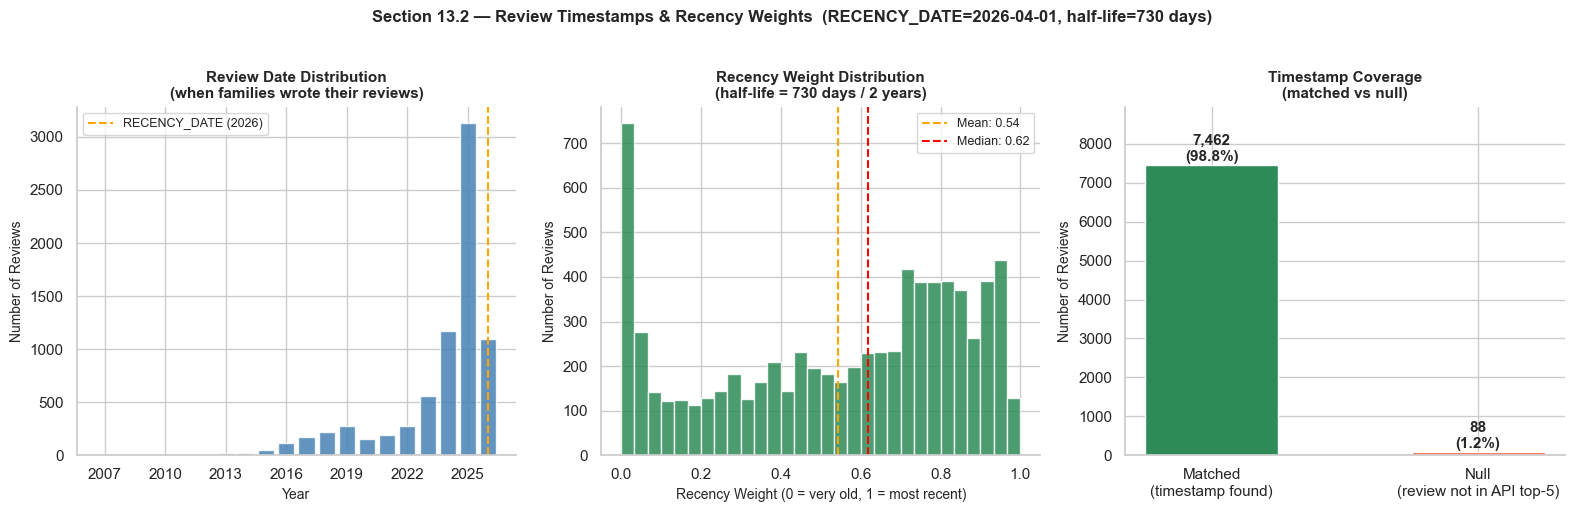

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/eda/eda_13_2_review_timestamps.png


In [55]:
# ── 13.2.3: Review Timestamp Visualisations ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Review Date Distribution ─────────────────────────────────────
# Shows the temporal spread of reviews — justifies why recency weighting
# matters (older reviews should carry less weight than recent ones)
review_years = df_reviews['review_date'].dt.year.dropna()
year_counts  = review_years.value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values,
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(RECENCY_DATE.year, color='orange', linestyle='--',
                linewidth=1.5, label=f'RECENCY_DATE ({RECENCY_DATE.year})')
axes[0].set_title('Review Date Distribution\n(when families wrote their reviews)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=10)
axes[0].set_ylabel('Number of Reviews', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Plot 2: Recency Weight Distribution ──────────────────────────────────
# Shows how weights are distributed — most reviews are recent enough to
# carry meaningful weight; the 2-year half-life is not overly aggressive
weights = df_reviews['recency_weight'].dropna()
axes[1].hist(weights, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(weights.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean: {weights.mean():.2f}')
axes[1].axvline(weights.median(), color='red', linestyle='--',
                linewidth=1.5, label=f'Median: {weights.median():.2f}')
axes[1].set_title('Recency Weight Distribution\n(half-life = 730 days / 2 years)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Recency Weight (0 = very old, 1 = most recent)', fontsize=10)
axes[1].set_ylabel('Number of Reviews', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Plot 3: Timestamp Coverage ────────────────────────────────────────────
# Shows the 99% match rate — validates the timestamp extraction was successful
matched_count = df_reviews['review_timestamp'].notna().sum()
null_count    = df_reviews['review_timestamp'].isna().sum()
bars = axes[2].bar(
    ['Matched\n(timestamp found)', 'Null\n(review not in API top-5)'],
    [matched_count, null_count],
    color=['seagreen', 'tomato'], edgecolor='white', width=0.5
)
for bar, count in zip(bars, [matched_count, null_count]):
    pct = count / len(df_reviews) * 100
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 20,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].set_title('Timestamp Coverage\n(matched vs null)',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of Reviews', fontsize=10)
axes[2].set_ylim(0, max(matched_count, null_count) * 1.2)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(
    f'Section 13.2 — Review Timestamps & Recency Weights  '
    f'(RECENCY_DATE={RECENCY_DATE.date()}, half-life=730 days)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda', 'eda_13_2_review_timestamps.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGES_DIR, "eda/eda_13_2_review_timestamps.png")}')


#### 13.2.4 — Deduplicate and Save


In [56]:
# ── 13.2.4: Deduplicate and Save ───────────────────────────────────────────────

# Deduplicate — multiple Google Places matches per center can produce duplicate
# (OPERATION_ID, review_text) pairs. Keep first occurrence.
n_before = len(df_reviews)
df_reviews = df_reviews.drop_duplicates(subset=['OPERATION_ID', 'review_text'])
n_after   = len(df_reviews)

print('=== Deduplication ===')
print(f'Rows before : {n_before:,}')
print(f'Rows after  : {n_after:,}  ({n_before - n_after:,} duplicates removed)')
print(f'Unique centers: {df_reviews["OPERATION_ID"].nunique():,}')
print()

# Save final model-ready file
df_reviews.to_csv('data/processed/model2_reviews.csv', index=False)

print('=== Files saved ===')
print(f'  model2_reviews_pre_timestamp.csv  — original clean file, no timestamps')
print(f'  model2_reviews.csv                — final model-ready file with timestamps and recency weights')
print()
print(f'Final shape     : {df_reviews.shape}')
print(f'Columns         : {df_reviews.columns.tolist()}')


=== Deduplication ===
Rows before : 7,550
Rows after  : 7,550  (0 duplicates removed)
Unique centers: 1,660

=== Files saved ===
  model2_reviews_pre_timestamp.csv  — original clean file, no timestamps
  model2_reviews.csv                — final model-ready file with timestamps and recency weights

Final shape     : (7550, 12)
Columns         : ['OPERATION_ID', 'OPERATION_NAME', 'CITY', 'place_id', 'google_rating', 'review_text', 'review_rating', 'match_confidence', 'review_timestamp', 'review_date', 'days_since_review', 'recency_weight']


## 14. Summary & Next Steps

This section consolidates the key findings from the EDA (Sections 11.1–11.7) and the Ridge Regression baseline (Section 12), and outlines the modelling work to be completed in the analysis notebooks.


### 14.1 Key EDA Findings

**Target Variable**

Mean rating 4.46, median 4.60, std 0.584. 59.9% of centers are rated between 4.5 and 5.0. Fewer than 6% of centers are rated below 3.5 stars, and the 1.0 to 2.0 range covers only 0.6% of centers. Positivity bias is consistent across all five cities and is not driven by any single geography.

**Regulatory Feature Distributions**

- All deficiency count features are right-skewed
- DEFICIENCY_MEDIUM_LOW and DEFICIENCY_LOW both have a median of 0.0, meaning more than half of centers received zero violations in these lower-severity categories
- TOTAL_ASSESSMENTS has a median of 0.0, meaning most centers have never undergone a formal assessment
- TOTAL_CAPACITY ranges from small centers to facilities up to 999 capacity (median 100)

**Feature Correlations**

- All 15 features show weak negative correlations with Google rating (maximum ACCEPTS_SUBSIDIES at -0.20)
- No single regulatory feature is a meaningful predictor of family-assigned ratings
- Deficiency tier features are highly multicollinear (pairwise correlations 0.67 to 0.96)
- TOTAL_INSPECTIONS shows only -0.09 linear correlation despite being a top SHAP feature, confirming the relationship is non-linear

**Scatter Plots**

No linear structure is visible in any of the 12 feature vs rating scatter plots. Centers with high deficiency rates still frequently carry 4.0 to 5.0 star ratings. The pattern is consistent across all five cities.

**Outlier Analysis**

- DEFICIENCY_LOW has the most outliers at 315 (14.4%), driven by most centers having zero low-severity violations
- YEARS_IN_OPERATION has zero IQR outliers despite a range of over 40 years
- All outliers represent legitimate operational variation and are retained

**Review Text Corpus**

- 7,550 unique reviews across 1,697 centers, median 77 words per review
- 86.8% of individual reviews are 5-star and 9.4% are 1-star, reflecting an extreme positivity bias at the review level
- 87.6% of centers have exactly 5 reviews (Google Places API cap)

### 14.2 Baseline Model Results (Section 12)

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Naive baseline (predict mean) | 0.6097 | 0.4452 | -0.0000 |
| Ridge Regression (GridSearchCV, alpha=100) | 0.5881 | 0.4161 | 0.0695 |

Ridge improves over the naive floor by 3.5%. R² of 0.0695 confirms that regulatory compliance data explains approximately 7% of the variance in Google ratings. ACCEPTS SUBSIDIES is the largest model coefficient (-0.10), followed by CITY DALLAS (-0.085) — socioeconomic and geographic effects outweigh any individual regulatory signal. Polynomial features (degree 2 and 3) do not improve RMSE, confirming the linear baseline is appropriate.

### 14.3 Next Steps (Analysis Notebooks)

**Model 1 (Notebook 01)**

- XGBoost regression and classification with iterative 3-round grid search for hyperparameter tuning
- SHAP feature importance to identify which regulatory features drive predictions most strongly
- SHAP city interaction analysis to quantify how city context modifies compliance feature effects

**Model 2A: Center-Level Text (Notebook 02)**

- TF-IDF vectorisation of 7,550 review texts aggregated to center level (one document per center)
- TF-IDF + Ridge Regression compared directly to Model 1 regression on the same 1,697 centers and same train/test split
- TF-IDF + Logistic Regression for center-level classification compared to Model 1 classification

**Model 2B: Individual Review Text with Center-Aligned Split (Notebook 03)**

- Individual reviews trained with center-level google_rating labels (same 4.5-star threshold as Model 1)
- Center-aligned split ensures the same 1,357 train / 340 test centers as Model 1 for a valid comparison
- After prediction, individual review scores are aggregated to center level using two methods: recency-weighted mean (more recent reviews carry higher weight) and simple mean (equal weight for all reviews)
- Key finding from the analysis: simple mean (AUC=0.8034) outperformed recency-weighted mean (AUC=0.7638), confirming that with only 5 reviews per center, temporal weighting amplifies noise rather than improving the signal

**Cross-Model Comparison (Notebook 04)**

- All model results are loaded from pickle files and compared in a single comparison table
- Center-level ROC curves compare Model 1, Model 2A, and Model 2B on the same centers
- Plain-language findings answer the research question for each stakeholder